# 1. Failure Prediction

This notebook builds the failure-prediction pipeline for the Smart School dataset.

The target is `exam_score`. The school decision is based on a threshold of 50, so the analysis keeps both views: score prediction and detection of students at risk of failing.

The workflow is:

1. inspect the dataset and the target;
2. study missing values, distributions and feature-target relationships;
3. select and create a small set of interpretable features;
4. build a preprocessing pipeline;
5. compare several models against a baseline;
6. tune the selected model and check overfitting.


## 1.1 Data Exploration and Analysis


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# Plotting setup.
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 80)
pd.plotting.register_matplotlib_converters()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("../student_dataset/student_failure/train.csv")
RANDOM_STATE = 42

In [2]:
import json
import pickle
import time

ARTIFACTS_DIR = Path("outputs/part1")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


def _artifact_path(filename, ext, folder=None):
    directory = ARTIFACTS_DIR if folder is None else ARTIFACTS_DIR / folder
    directory.mkdir(parents=True, exist_ok=True)
    return directory / f"{filename}.{ext}"


def save_table(df, filename, folder=None):
    if isinstance(df, pd.Series):
        df = df.to_frame()
    path = _artifact_path(filename, "csv", folder=folder)
    df.to_csv(path, index=False)
    return path


def save_figure(filename, folder=None, fig=None):
    if fig is None:
        fig = plt.gcf()
    path = _artifact_path(filename, "png", folder=folder)
    fig.savefig(path, bbox_inches="tight", dpi=160)
    return path


def save_model(model, filename, folder=None):
    path = _artifact_path(filename, "pkl", folder=folder)
    with open(path, "wb") as file:
        pickle.dump(model, file)
    return path


def save_json(payload, filename, folder=None):
    path = _artifact_path(filename, "json", folder=folder)
    with open(path, "w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, ensure_ascii=False)
    return path

In [3]:
# Load the raw Smart School tabular dataset.
raw_data = pd.read_csv(DATA_PATH)
raw_data.shape

(630000, 15)

### 1.1.1 Dataset Structure

In [4]:
data = raw_data.copy()
data.columns = [
    "id",
    "age",
    "gender",
    "degree",
    "study_hours",
    "class_attendance",
    "internet_access",
    "sleep_hours",
    "sleep_quality",
    "study_method",
    "school_evaluation",
    "exam_difficulty",
    "exam_score",
    "party_hours",
    "student_height",
]

data.head()

,id,age,gender,degree,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,school_evaluation,exam_difficulty,exam_score,party_hours,student_height
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


In [5]:
# Display column types.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 630000 non-null  int64  
 1   age                630000 non-null  int64  
 2   gender             630000 non-null  str    
 3   degree             630000 non-null  str    
 4   study_hours        611100 non-null  float64
 5   class_attendance   630000 non-null  float64
 6   internet_access    567000 non-null  str    
 7   sleep_hours        630000 non-null  float64
 8   sleep_quality      630000 non-null  str    
 9   study_method       585900 non-null  str    
 10  school_evaluation  630000 non-null  str    
 11  exam_difficulty    630000 non-null  str    
 12  exam_score         630000 non-null  float64
 13  party_hours        630000 non-null  int64  
 14  student_height     630000 non-null  float64
dtypes: float64(5), int64(3), str(7)
memory usage: 72.1 MB


In [6]:
# Summarise structure, missingness and cardinality.
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "missing_count": data.isna().sum(),
    "missing_pct": (data.isna().mean() * 100).round(2),
    "unique_values": data.nunique(dropna=False),
})

save_table(summary, "dataset_structure_summary", folder="1_1_1_dataset_structure")
summary

,dtype,missing_count,missing_pct,unique_values
id,int64,0,0.0,630000
age,int64,0,0.0,8
gender,str,0,0.0,2
degree,str,0,0.0,7
study_hours,float64,18900,3.0,793
class_attendance,float64,0,0.0,617
internet_access,str,63000,10.0,3
sleep_hours,float64,0,0.0,66
sleep_quality,str,0,0.0,3
study_method,str,44100,7.0,6


In [7]:
print(f"Number of rows: {data.shape[0]:,}")
print(f"Number of columns: {data.shape[1]}")
print(f"Duplicated rows: {data.duplicated().sum():,}")
print(f"Duplicated student/exam ids: {data['id'].duplicated().sum():,}")

Number of rows: 630,000
Number of columns: 15
Duplicated rows: 0
Duplicated student/exam ids: 0


**Structural observations**

- The dataset contains **630,000 rows** and **15 columns**.
- The target is `exam_score`, a continuous grade capped at 100.
- `id` is an identifier and should not be used as a predictor.
- Missing values are concentrated in `internet_access`, `study_method`, and `study_hours`.


### 1.1.2 Target Analysis

The model predicts a continuous score, but the operational threshold is 50. I therefore inspect both the score distribution and the proportion of failing observations.


In [8]:
# Define the target and the operational failure threshold.
target = "exam_score"
failure_threshold = 50

save_table(data[target].describe().round(2), "target_variable_summary", folder="1_1_2_target_variable_analysis")
data[target].describe()

count    630000.000000
mean         63.406789
std          18.950840
min          12.600000
25%          49.600000
50%          63.620000
75%          77.300000
max         100.000000
Name: exam_score, dtype: float64

In [9]:
# Convert the threshold into a binary risk indicator for diagnostics.
data["is_at_risk"] = data[target] < failure_threshold
failure_rate = data["is_at_risk"].mean()

print(f"Students below {failure_threshold}: {data['is_at_risk'].sum():,}")
print(f"At-risk rate: {failure_rate:.2%}")

save_table(data[target].describe().to_frame(name=target), "target_summary", folder="1_1_2_target_analysis")

Students below 50: 161,083
At-risk rate: 25.57%


WindowsPath('outputs/part1/1_1_2_target_analysis/target_summary.csv')

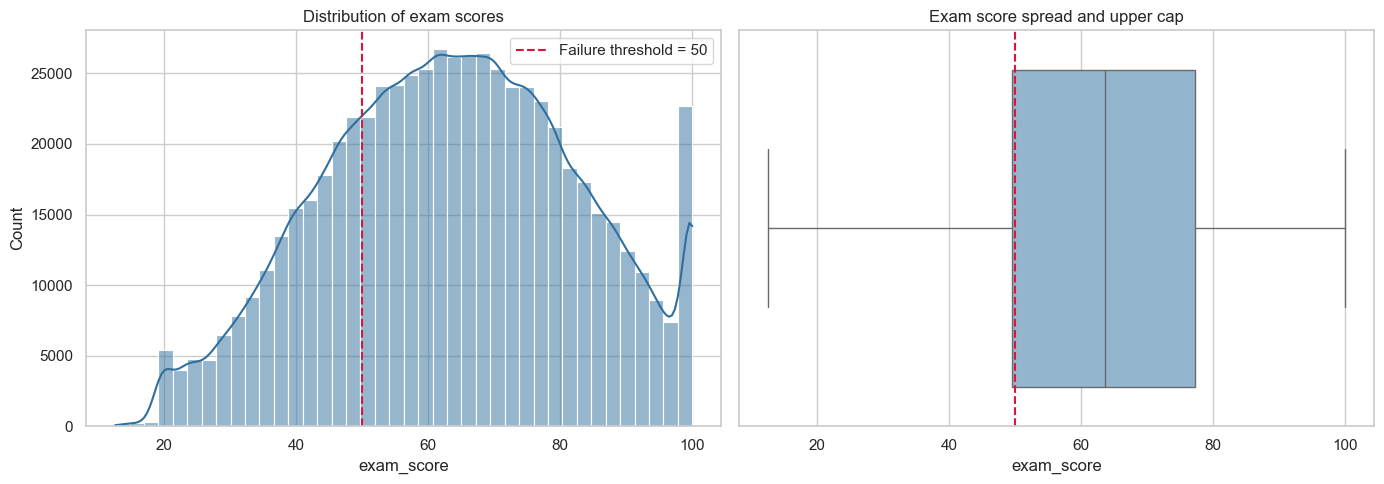

WindowsPath('outputs/part1/1_1_2_target_analysis/target_distribution.png')

In [10]:
# Plot the score distribution and the pass/fail balance.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=data, x=target, bins=40, kde=True, ax=axes[0], color="#2f6f9f")
axes[0].axvline(failure_threshold, color="crimson", linestyle="--", label="Failure threshold = 50")
axes[0].set_title("Distribution of exam scores")
axes[0].legend()

sns.boxplot(data=data, x=target, ax=axes[1], color="#8ab6d6")
axes[1].axvline(failure_threshold, color="crimson", linestyle="--")
axes[1].set_title("Exam score spread and upper cap")

plt.tight_layout()
plt.show()
save_figure("target_distribution", folder="1_1_2_target_analysis", fig=fig)

**Target observations.** The mean score is about **63.4**, and around **25.6%** of observations are below 50. The cap at 100 creates a ceiling effect, which can make excellent students harder to model precisely.


### 1.1.3 Missing Values

Dropping rows with missing values would remove too much information. The first step is to quantify where missingness appears and whether it is related to the target.


In [11]:
# Rank columns by missing-value frequency.
missing = (
    data.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: (x["missing_count"] / len(data) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)

save_table(missing, "missing_summary", folder="1_1_3_missing_values")
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
internet_access,63000,10.0
study_method,44100,7.0
study_hours,18900,3.0


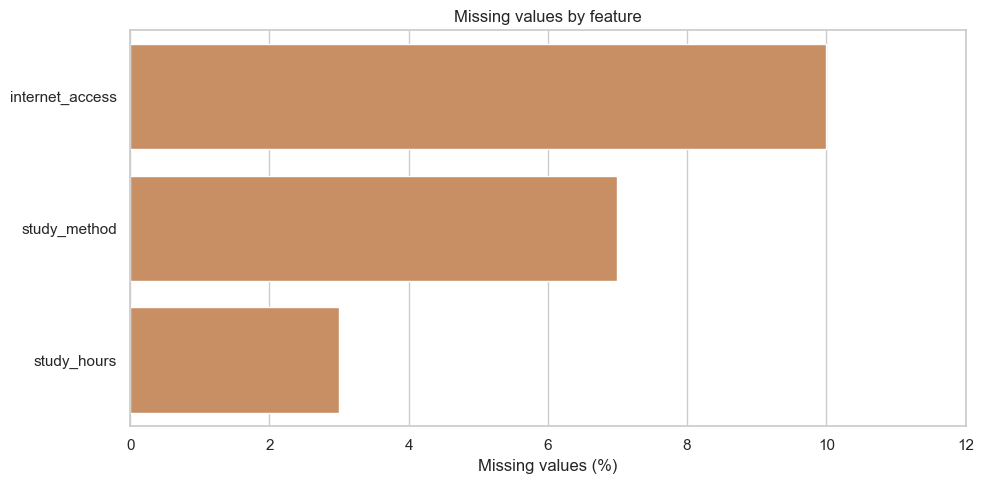

WindowsPath('outputs/part1/1_1_3_missing_values/missing_values_by_feature.png')

In [12]:
# Visualise only columns where missingness actually occurs.
missing_to_plot = missing[missing["missing_count"] > 0].reset_index(names="feature")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=missing_to_plot, x="missing_pct", y="feature", color="#d98c54", ax=ax)
ax.set_title("Missing values by feature")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")
ax.set_xlim(0, max(12, missing_to_plot["missing_pct"].max() + 1))
fig.tight_layout()
plt.show()
save_figure("missing_values_by_feature", folder="1_1_3_missing_values", fig=fig)

In [13]:
# Check whether missingness is related to the target.
missing_effects = []
for col in ["internet_access", "study_method", "study_hours"]:
    tmp = data.assign(is_missing=data[col].isna())
    stats = tmp.groupby("is_missing")[target].agg(["count", "mean", "median"])
    stats["feature"] = col
    missing_effects.append(stats.reset_index())

save_table(
    pd.concat(missing_effects, ignore_index=True)[["feature", "is_missing", "count", "mean", "median"]],
    "missingness_effects",
    folder="1_1_3_missing_values",
)
pd.concat(missing_effects, ignore_index=True)[["feature", "is_missing", "count", "mean", "median"]]

,feature,is_missing,count,mean,median
0,internet_access,False,567000,63.404588,63.60
1,internet_access,True,63000,63.426597,63.70
2,study_method,False,585900,63.400342,63.60
3,study_method,True,44100,63.492443,63.76
4,study_hours,False,611100,63.409582,63.63
5,study_hours,True,18900,63.316499,63.34


**Missing-value observations.** `internet_access` has about **10%** missing values, `study_method` about **7%**, and `study_hours` about **3%**. Since missingness is not random for some variables, the preprocessing should keep missingness indicators instead of only imputing values.


### 1.1.4 Numerical Feature Distributions

The numerical variables are inspected with descriptive statistics, histograms and boxplots. This gives a first view of scale, spread, skewness and possible outliers.


In [14]:
# List numerical predictors used in the EDA.
numeric_features = [
    "age",
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "party_hours",
    "student_height",
]

save_table(data[numeric_features + [target]].describe().T, "numeric_features_summary", folder="1_1_4_feature_analysis")
data[numeric_features + [target]].describe().T

,count,mean,std,min,25%,50%,75%,max
age,630000.0,20.545821,2.260238,17.00,19.00,21.00,23.00,24.00
study_hours,611100.0,4.002779,2.359388,0.08,1.98,4.01,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.60,57.00,72.60,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.10,5.60,7.10,8.60,9.90
party_hours,630000.0,4.000514,2.000382,0.00,3.00,4.00,5.00,19.00
student_height,630000.0,1.754836,0.131891,1.48,1.66,1.75,1.85,2.03
exam_score,630000.0,63.406789,18.950840,12.60,49.60,63.62,77.30,100.00


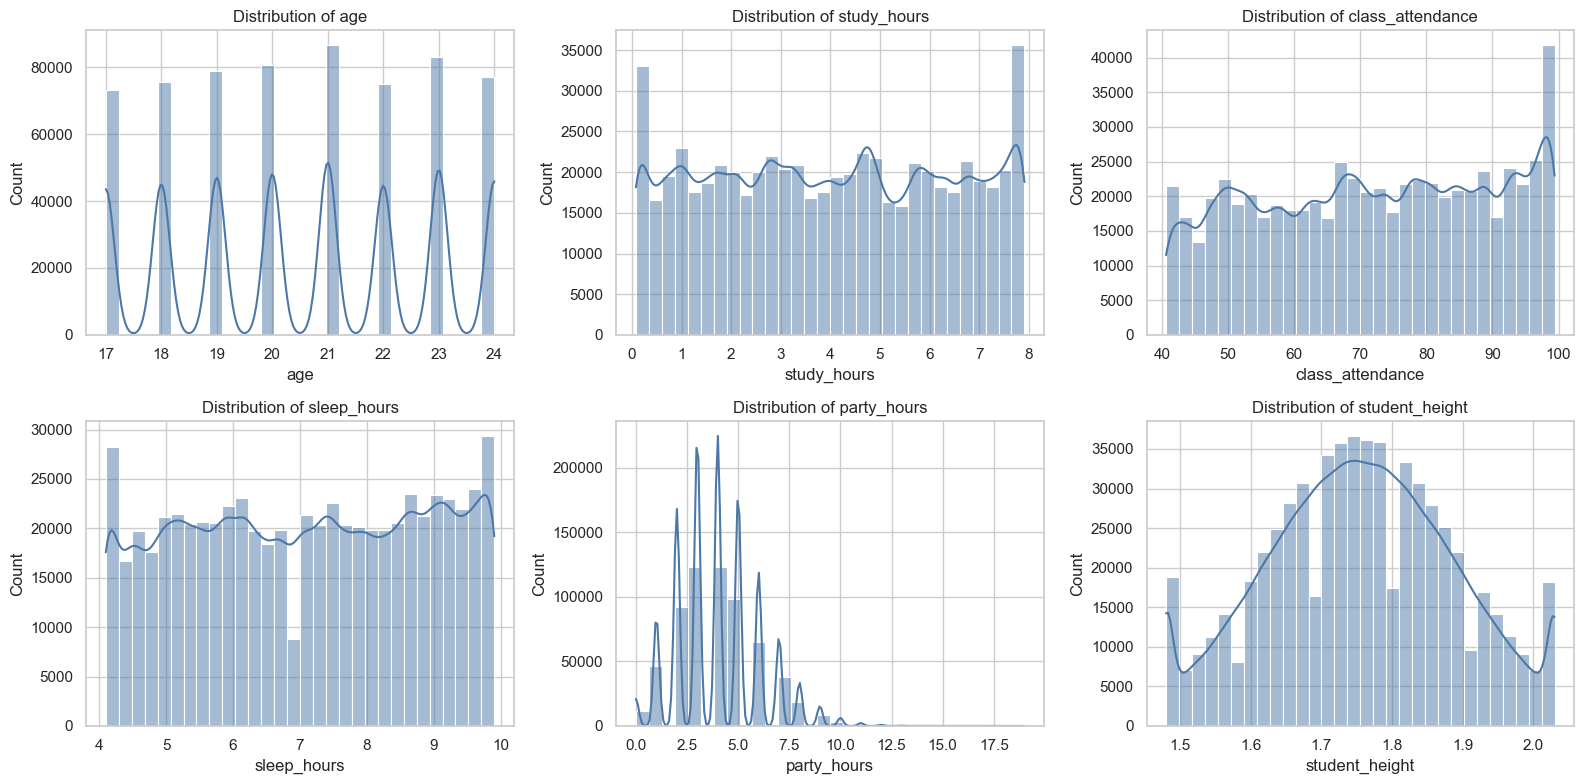

WindowsPath('outputs/part1/1_1_4_numerical_distributions/numeric_feature_distributions.png')

In [15]:
# Plot numerical distributions to inspect scale and skewness.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_features):
    sns.histplot(data=data, x=col, bins=30, kde=True, ax=ax, color="#4c78a8")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()
save_figure("numeric_feature_distributions", folder="1_1_4_numerical_distributions", fig=fig)

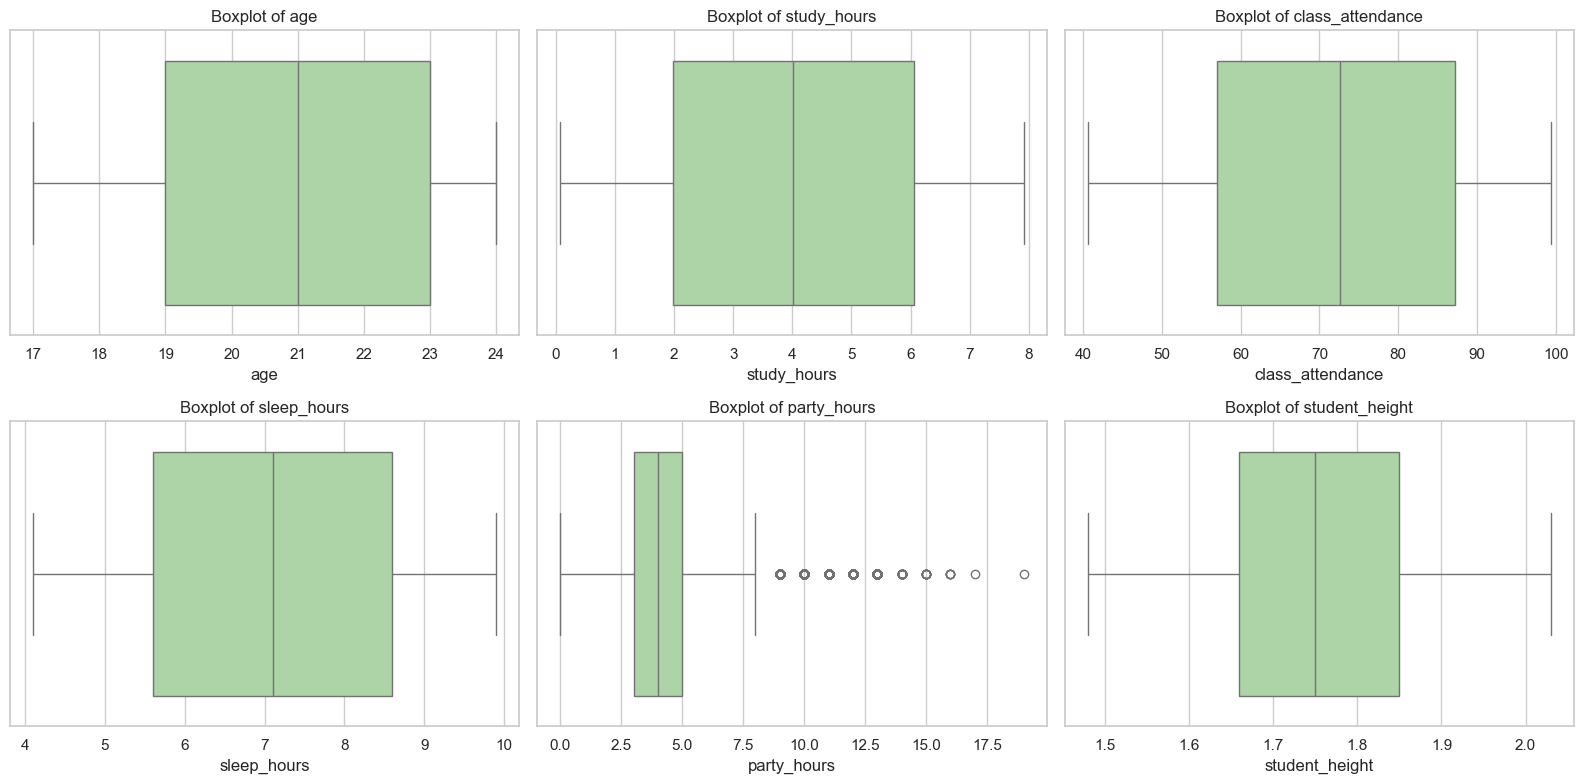

WindowsPath('outputs/part1/1_1_4_numerical_distributions/numeric_feature_boxplots.png')

In [16]:
# Use boxplots to make outliers and compact ranges visible.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_features):
    sns.boxplot(data=data, x=col, ax=ax, color="#a6dba0")
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()
save_figure("numeric_feature_boxplots", folder="1_1_4_numerical_distributions", fig=fig)

### 1.1.5 Categorical Feature Distributions


In [17]:
# List categorical predictors used in the EDA.
categorical_features = [
    "gender",
    "degree",
    "internet_access",
    "sleep_quality",
    "study_method",
    "school_evaluation",
    "exam_difficulty",
]

for col in categorical_features:
    display(
        data[col]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(pct=lambda x: (x["count"] / len(data) * 100).round(2))
    )
    save_table(
        data[col]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(pct=lambda x: (x["count"] / len(data) * 100).round(2)),
        f"{col}_distribution",
        folder="1_1_5_categorical_distributions",
    )

,count,pct
gender,,
male,365662,58.04
female,264338,41.96


,count,pct
degree,,
Engineering,131236,20.83
Computer Science,111554,17.71
Marketing,110932,17.61
Business Management,88721,14.08
Business Administration,75644,12.01
Bachelor of Arts,61989,9.84
Law,49924,7.92


,count,pct
internet_access,,
yes,521430,82.77
NaN,63000,10.00
no,45570,7.23


,count,pct
sleep_quality,,
poor,213675,33.92
good,213089,33.82
average,203236,32.26


,count,pct
study_method,,
coaching,122444,19.44
self-study,122050,19.37
mixed,114488,18.17
group study,114420,18.16
online videos,112498,17.86
NaN,44100,7.00


,count,pct
school_evaluation,,
medium,214082,33.98
low,212378,33.71
high,203540,32.31


,count,pct
exam_difficulty,,
moderate,353982,56.19
easy,176540,28.02
hard,99478,15.79


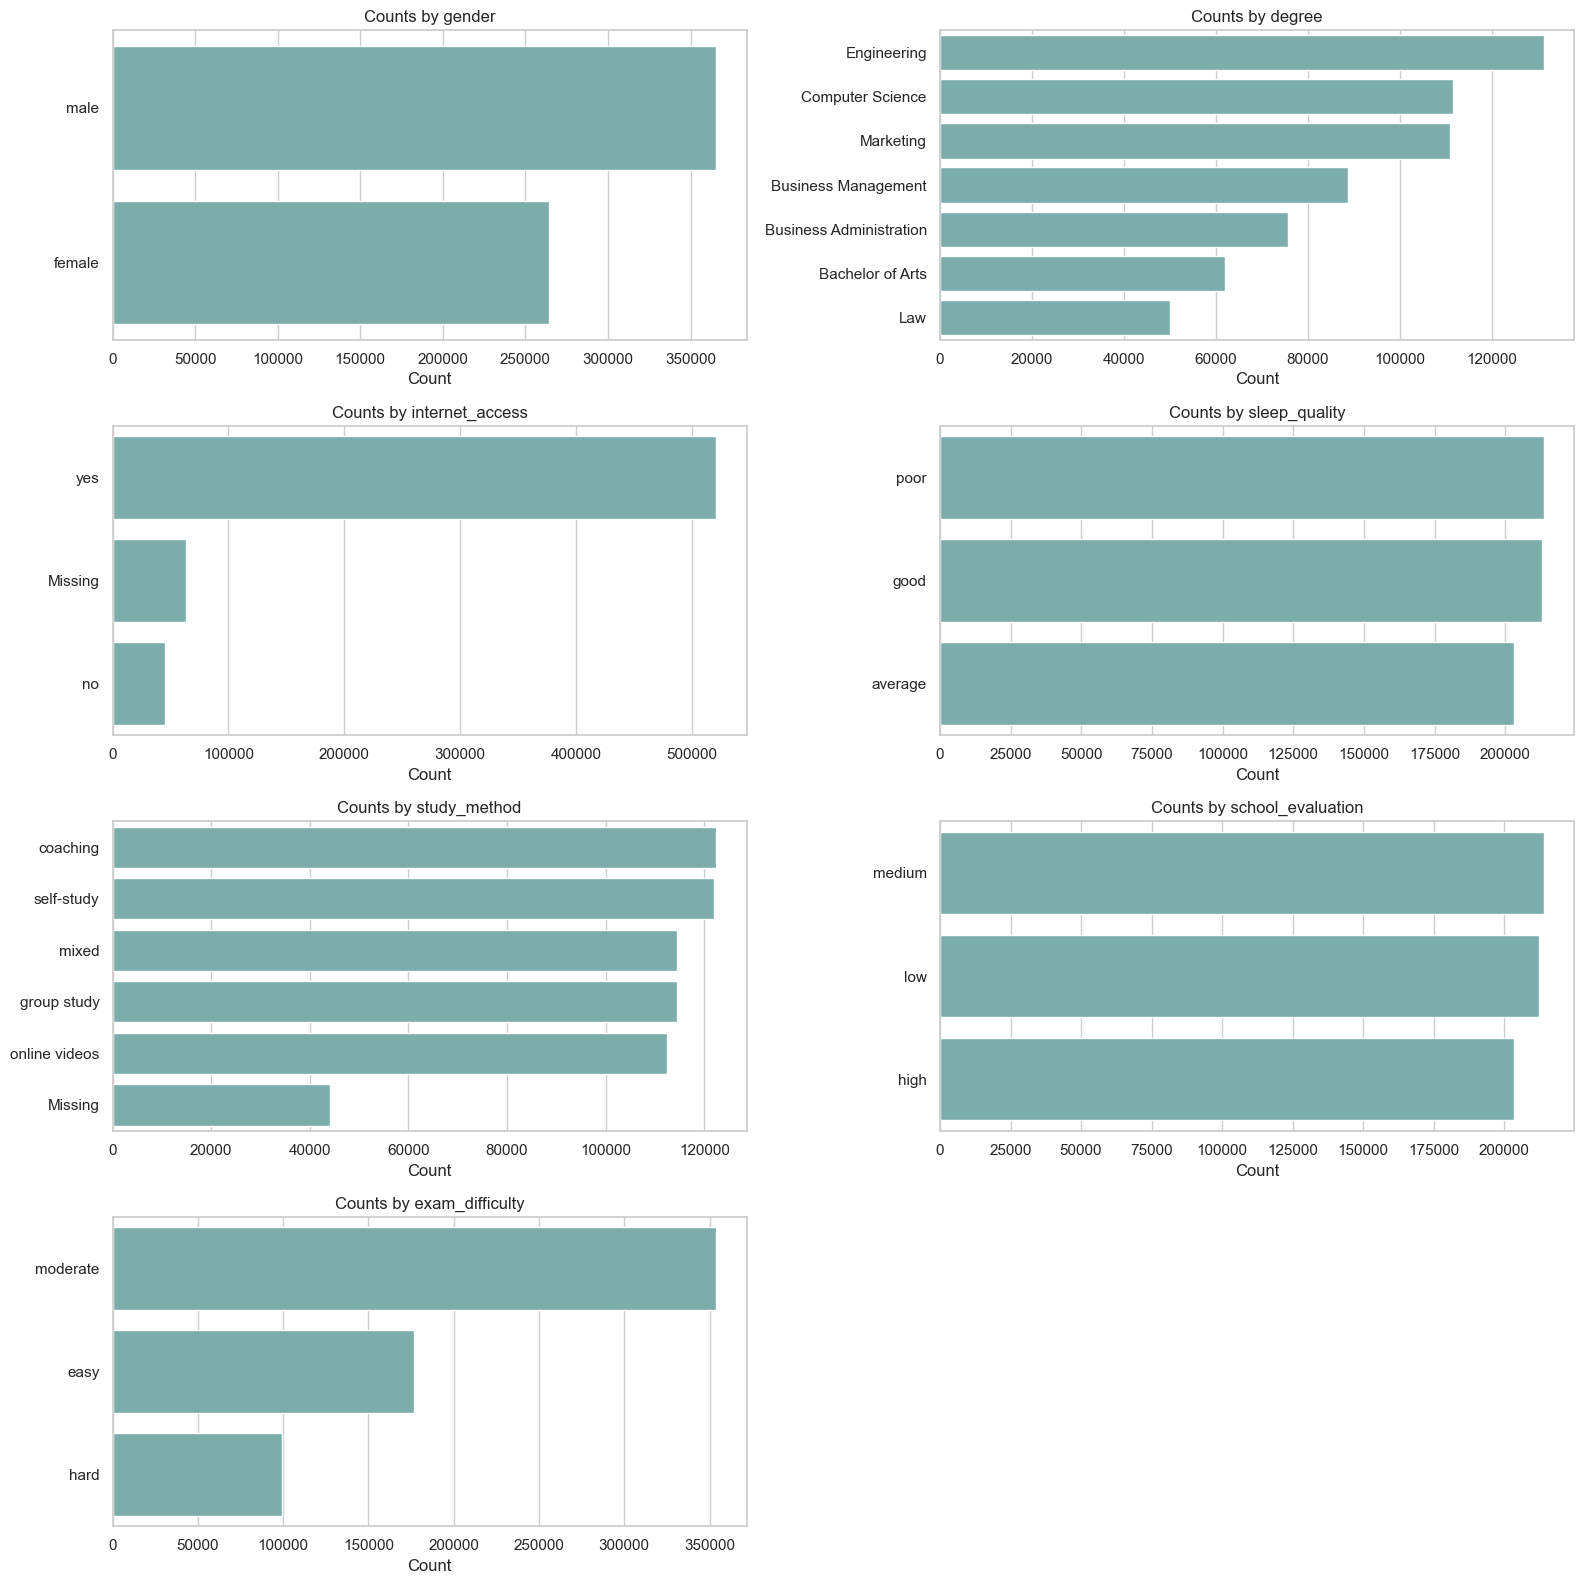

WindowsPath('outputs/part1/1_1_5_categorical_distributions/categorical_feature_distributions.png')

In [18]:
# Plot category frequencies for each categorical variable.
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.ravel()

for ax, col in zip(axes, categorical_features):
    plot_data = data.assign(**{col: data[col].fillna("Missing").astype(str)})
    order = plot_data[col].value_counts(dropna=False).index
    sns.countplot(data=plot_data, y=col, order=order, ax=ax, color="#72b7b2")
    ax.set_title(f"Counts by {col}")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

axes[-1].axis("off")
plt.tight_layout()
plt.show()
save_figure("categorical_feature_distributions", folder="1_1_5_categorical_distributions", fig=fig)

### 1.1.6 Numerical Relationships With Exam Score

This section checks how continuous variables move with `exam_score`. Correlation is only an exploratory signal, but it is useful for identifying variables that deserve attention during modelling.


In [19]:
# Compute linear association between numerical features and the score.
correlation_with_target = (
    data[numeric_features + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

save_table(correlation_with_target.to_frame("correlation_with_exam_score"), "numeric_feature_correlations", folder="1_1_6_feature_target_relationships")
correlation_with_target.to_frame("correlation_with_exam_score")

,correlation_with_exam_score
study_hours,0.757648
class_attendance,0.359452
sleep_hours,0.165891
age,0.010010
party_hours,-0.000785
student_height,0.000723


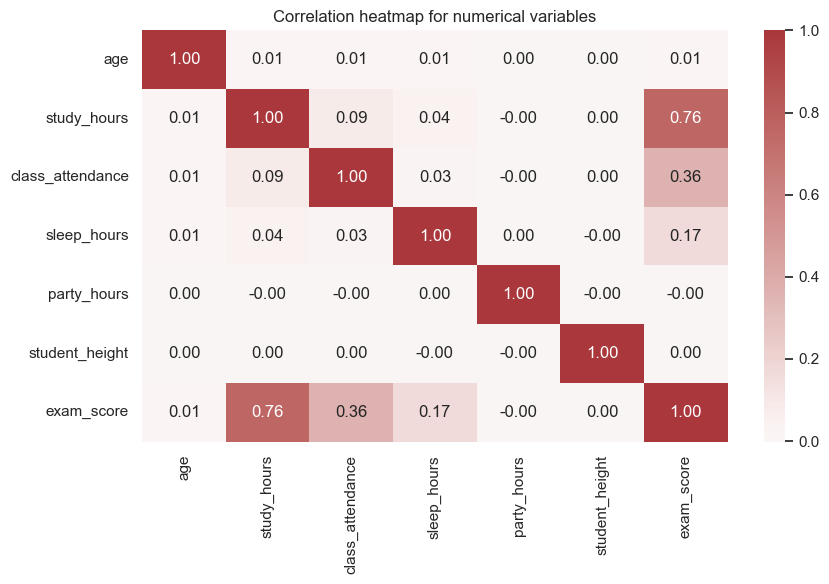

WindowsPath('outputs/part1/1_1_6_numerical_relationships/correlation_heatmap.png')

In [20]:
# Visualise the relative strength of numerical correlations.
fig = plt.figure(figsize=(9, 6))
sns.heatmap(
    data[numeric_features + [target]].corr(numeric_only=True),
    annot=True,
    cmap="vlag",
    center=0,
    fmt=".2f",
)
plt.title("Correlation heatmap for numerical variables")
plt.tight_layout()
plt.show()
save_figure("correlation_heatmap", folder="1_1_6_numerical_relationships", fig=fig)

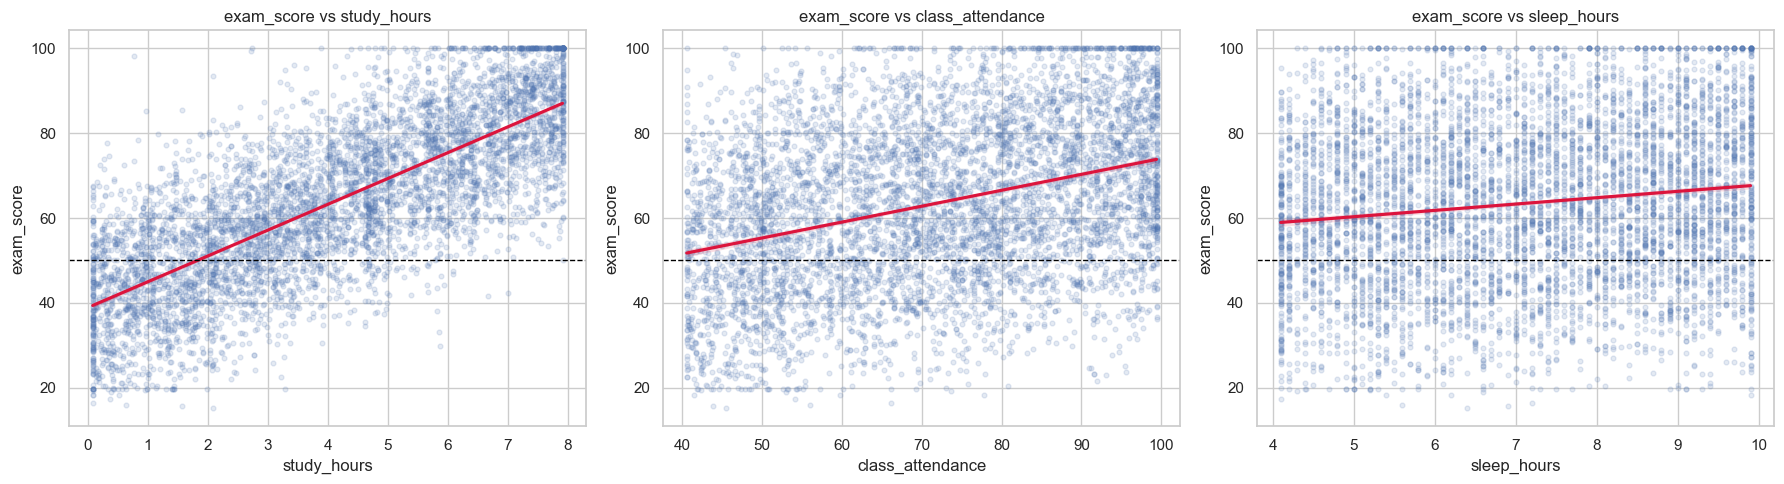

WindowsPath('outputs/part1/1_1_6_numerical_relationships/scatter_relationships_exam_score.png')

In [21]:
# Sample the scatter plots for readability.
plot_sample = data.sample(n=6000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["study_hours", "class_attendance", "sleep_hours"]):
    sns.regplot(
        data=plot_sample,
        x=col,
        y=target,
        scatter_kws={"alpha": 0.15, "s": 12},
        line_kws={"color": "crimson"},
        ax=ax,
    )
    ax.axhline(failure_threshold, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{target} vs {col}")

plt.tight_layout()
plt.show()
save_figure("scatter_relationships_exam_score", folder="1_1_6_numerical_relationships", fig=fig)

In [22]:
# Binned means make the trends easier to compare.
for col in ["study_hours", "class_attendance", "sleep_hours", "party_hours"]:
    display(
        data.groupby(pd.qcut(data[col], q=5, duplicates="drop"), observed=True)[target]
        .agg(["count", "mean", "median"])
        .round(2)
    )
    save_table(
        data.groupby(pd.qcut(data[col], q=5, duplicates="drop"), observed=True)[target]
        .agg(["count", "mean", "median"])
        .round(2)
        .reset_index(names=col),
        f"{col}_binned_relationship",
        folder="1_1_6_numerical_relationships",
    )

,count,mean,median
study_hours,,,
"(0.079, 1.56]",122551,43.55,43.60
"(1.56, 3.17]",122728,52.99,52.80
"(3.17, 4.78]",122473,64.04,64.21
"(4.78, 6.45]",121543,73.57,73.55
"(6.45, 7.91]",121805,83.11,83.70


,count,mean,median
class_attendance,,,
"(40.599000000000004, 53.5]",127189,53.51,53.37
"(53.5, 66.9]",125265,58.98,58.62
"(66.9, 78.4]",125819,64.19,64.18
"(78.4, 90.0]",125851,67.84,68.30
"(90.0, 99.4]",125876,72.60,73.20


,count,mean,median
sleep_hours,,,
"(4.098999999999999, 5.3]",135580,59.11,58.99
"(5.3, 6.5]",125174,61.49,61.80
"(6.5, 7.7]",122533,63.22,63.30
"(7.7, 8.9]",125078,65.89,66.40
"(8.9, 9.9]",121635,67.80,67.90


,count,mean,median
party_hours,,,
"(-0.001, 2.0]",149853,63.41,63.63
"(2.0, 3.0]",123024,63.46,63.70
"(3.0, 4.0]",123356,63.34,63.50
"(4.0, 6.0]",164011,63.45,63.70
"(6.0, 19.0]",69756,63.32,63.56


**Numerical observations.** `study_hours` is the strongest numerical signal, with a correlation around **0.76**. `class_attendance` is also meaningful, and `sleep_hours` has a weaker positive relationship. `party_hours` and `student_height` add little linear signal.


### 1.1.7 Interactions Between Study Hours, Attendance and Sleep

Some effects may appear only when variables are combined. I look at the three pairwise relations separately: study hours with attendance, study hours with sleep, and attendance with sleep.


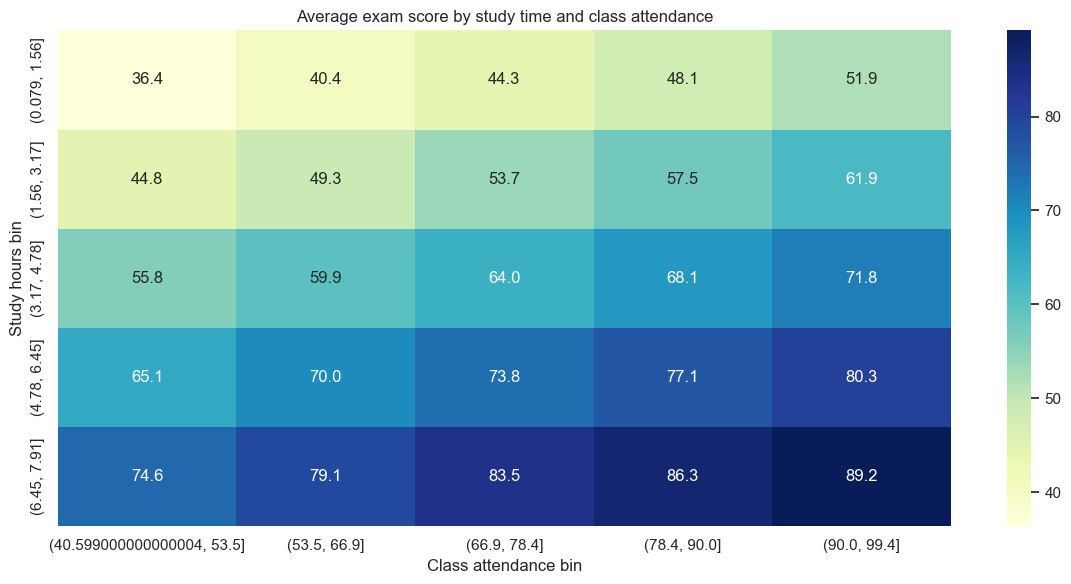

WindowsPath('outputs/part1/1_1_7_interaction_analysis/study_attendance_heatmap.png')

In [23]:
# Build a binned view of study time and attendance.
interaction_data = data.dropna(subset=["study_hours"]).copy()
interaction_data["study_bin"] = pd.qcut(interaction_data["study_hours"], q=5, duplicates="drop")
interaction_data["attendance_bin"] = pd.qcut(interaction_data["class_attendance"], q=5, duplicates="drop")

study_attendance_matrix = interaction_data.pivot_table(
    values=target,
    index="study_bin",
    columns="attendance_bin",
    aggfunc="mean",
    observed=True,
)

fig = plt.figure(figsize=(12, 6))
sns.heatmap(study_attendance_matrix, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average exam score by study time and class attendance")
plt.xlabel("Class attendance bin")
plt.ylabel("Study hours bin")
plt.tight_layout()
plt.show()
save_figure("study_attendance_heatmap", folder="1_1_7_interaction_analysis", fig=fig)

**Interaction observations.** Scores increase with both study time and attendance. The clearest risk profile is low study time combined with low attendance.


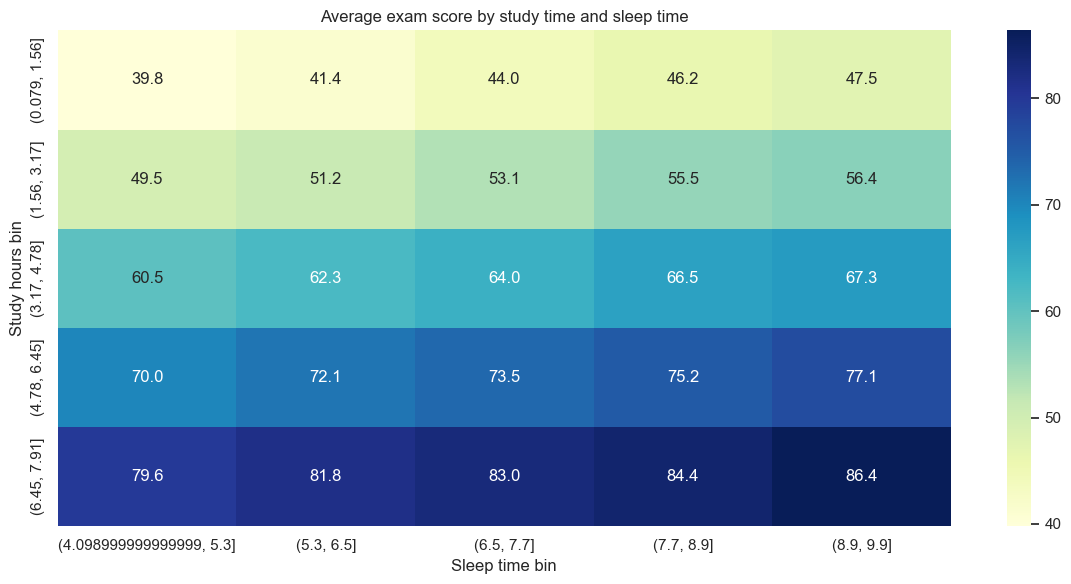

WindowsPath('outputs/part1/1_1_7_interaction_analysis/study_sleep_heatmap.png')

In [24]:
# Build a binned view of study time and sleep time.
interaction_data = data.dropna(subset=["study_hours", "sleep_hours"]).copy()
interaction_data["study_bin"] = pd.qcut(interaction_data["study_hours"], q=5, duplicates="drop")
interaction_data["sleep_bin"] = pd.qcut(interaction_data["sleep_hours"], q=5, duplicates="drop")

study_sleep_matrix = interaction_data.pivot_table(
    values=target,
    index="study_bin",
    columns="sleep_bin",
    aggfunc="mean",
    observed=True,
)

fig = plt.figure(figsize=(12, 6))
sns.heatmap(study_sleep_matrix, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average exam score by study time and sleep time")
plt.xlabel("Sleep time bin")
plt.ylabel("Study hours bin")
plt.tight_layout()
plt.show()
save_figure("study_sleep_heatmap", folder="1_1_7_interaction_analysis", fig=fig)

**Interaction observations.** Scores are highest when study time is high and sleep time is not too low. Very low study time combined with short sleep is associated with weaker outcomes, which suggests that sleep may reinforce the effect of study effort.

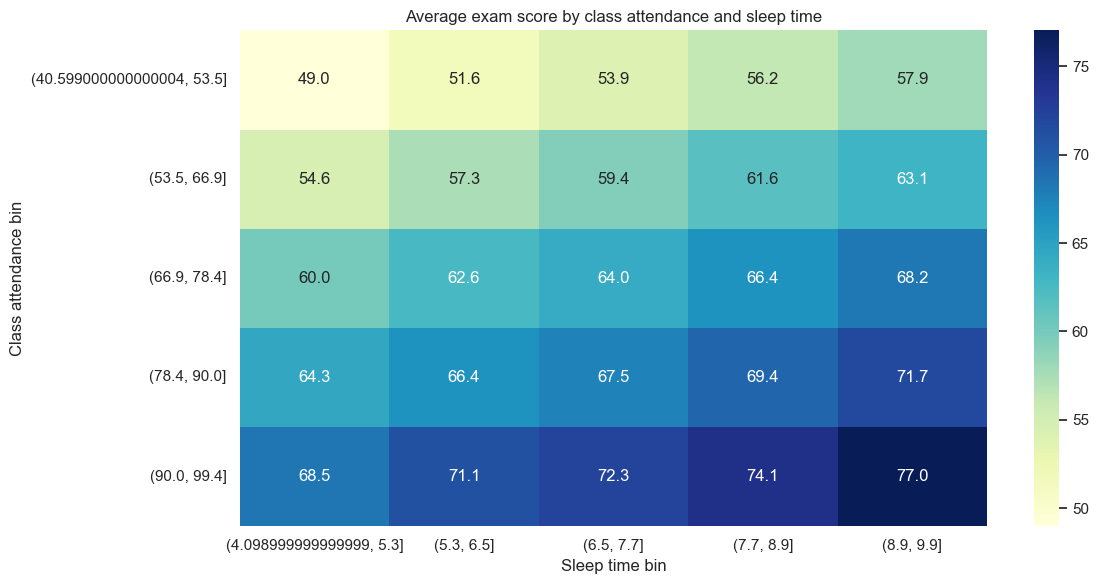

WindowsPath('outputs/part1/1_1_7_interaction_analysis/attendance_sleep_heatmap.png')

In [25]:
# Build a binned view of attendance and sleep time.
interaction_data = data.dropna(subset=["class_attendance", "sleep_hours"]).copy()
interaction_data["attendance_bin"] = pd.qcut(interaction_data["class_attendance"], q=5, duplicates="drop")
interaction_data["sleep_bin"] = pd.qcut(interaction_data["sleep_hours"], q=5, duplicates="drop")

attendance_sleep_matrix = interaction_data.pivot_table(
    values=target,
    index="attendance_bin",
    columns="sleep_bin",
    aggfunc="mean",
    observed=True,
)

fig = plt.figure(figsize=(12, 6))
sns.heatmap(attendance_sleep_matrix, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average exam score by class attendance and sleep time")
plt.xlabel("Sleep time bin")
plt.ylabel("Class attendance bin")
plt.tight_layout()
plt.show()
save_figure("attendance_sleep_heatmap", folder="1_1_7_interaction_analysis", fig=fig)

**Interaction observations.** Scores are highest when attendance and sleep are both reasonably high. Low attendance combined with short sleep is associated with weaker outcomes, so attendance and recovery time seem to work together in the same way as study effort and sleep.

### 1.1.8 Categorical Relationships With Exam Score

For categorical variables, I compare mean score, median score and failure rate by group. This highlights categories linked to stronger or weaker outcomes.


In [ ]:
# Aggregate score and failure statistics for one categorical feature.
def categorical_target_summary(df, feature, target_col=target):
    return (
        df.groupby(feature, dropna=False)[target_col]
        .agg(count="count", mean="mean", median="median", std="std")
        .assign(failure_rate=df.groupby(feature, dropna=False)["is_at_risk"].mean())
        .sort_values("mean", ascending=False)
        .round(3)
    )

for col in categorical_features:
    print(f"\n{col}")
    display(categorical_target_summary(data, col))
    save_table(
        categorical_target_summary(data, col).reset_index(),
        f"{col}_target_relationship",
        folder="1_1_7_categorical_relationships",
    )


gender


,count,mean,median,std,failure_rate
gender,,,,,
female,264338,65.037,65.17,18.768,0.228
male,365662,62.229,62.40,18.995,0.275



degree


,count,mean,median,std,failure_rate
degree,,,,,
Business Administration,75644,64.216,64.600,19.186,0.244
Marketing,110932,63.969,63.780,18.425,0.239
Business Management,88721,63.659,63.940,18.951,0.255
Law,49924,63.576,63.200,19.075,0.249
Bachelor of Arts,61989,63.360,63.900,18.783,0.260
Engineering,131236,62.850,62.755,18.912,0.265
Computer Science,111554,62.704,63.560,19.341,0.271



internet_access


,count,mean,median,std,failure_rate
internet_access,,,,,
yes,521430,63.725,64.000,18.873,0.249
NaN,63000,63.427,63.700,18.930,0.254
no,45570,59.737,59.155,19.475,0.329



sleep_quality


,count,mean,median,std,failure_rate
sleep_quality,,,,,
good,213089,68.773,69.20,18.112,0.163
average,203236,63.563,63.70,18.635,0.252
poor,213675,57.907,58.02,18.506,0.351



study_method


,count,mean,median,std,failure_rate
study_method,,,,,
coaching,122444,70.145,70.27,18.393,0.151
mixed,114488,65.996,66.70,18.259,0.207
NaN,44100,63.492,63.76,18.946,0.253
group study,114420,61.407,61.67,18.281,0.284
online videos,112498,60.664,60.60,18.804,0.298
self-study,122050,58.590,58.20,18.630,0.342



school_evaluation


,count,mean,median,std,failure_rate
school_evaluation,,,,,
high,203540,67.571,68.27,18.522,0.191
medium,214082,63.949,64.10,18.668,0.241
low,212378,58.869,59.19,18.648,0.333



exam_difficulty


,count,mean,median,std,failure_rate
exam_difficulty,,,,,
hard,99478,63.578,63.91,19.180,0.258
moderate,353982,63.497,63.60,18.990,0.254
easy,176540,63.129,63.59,18.739,0.258


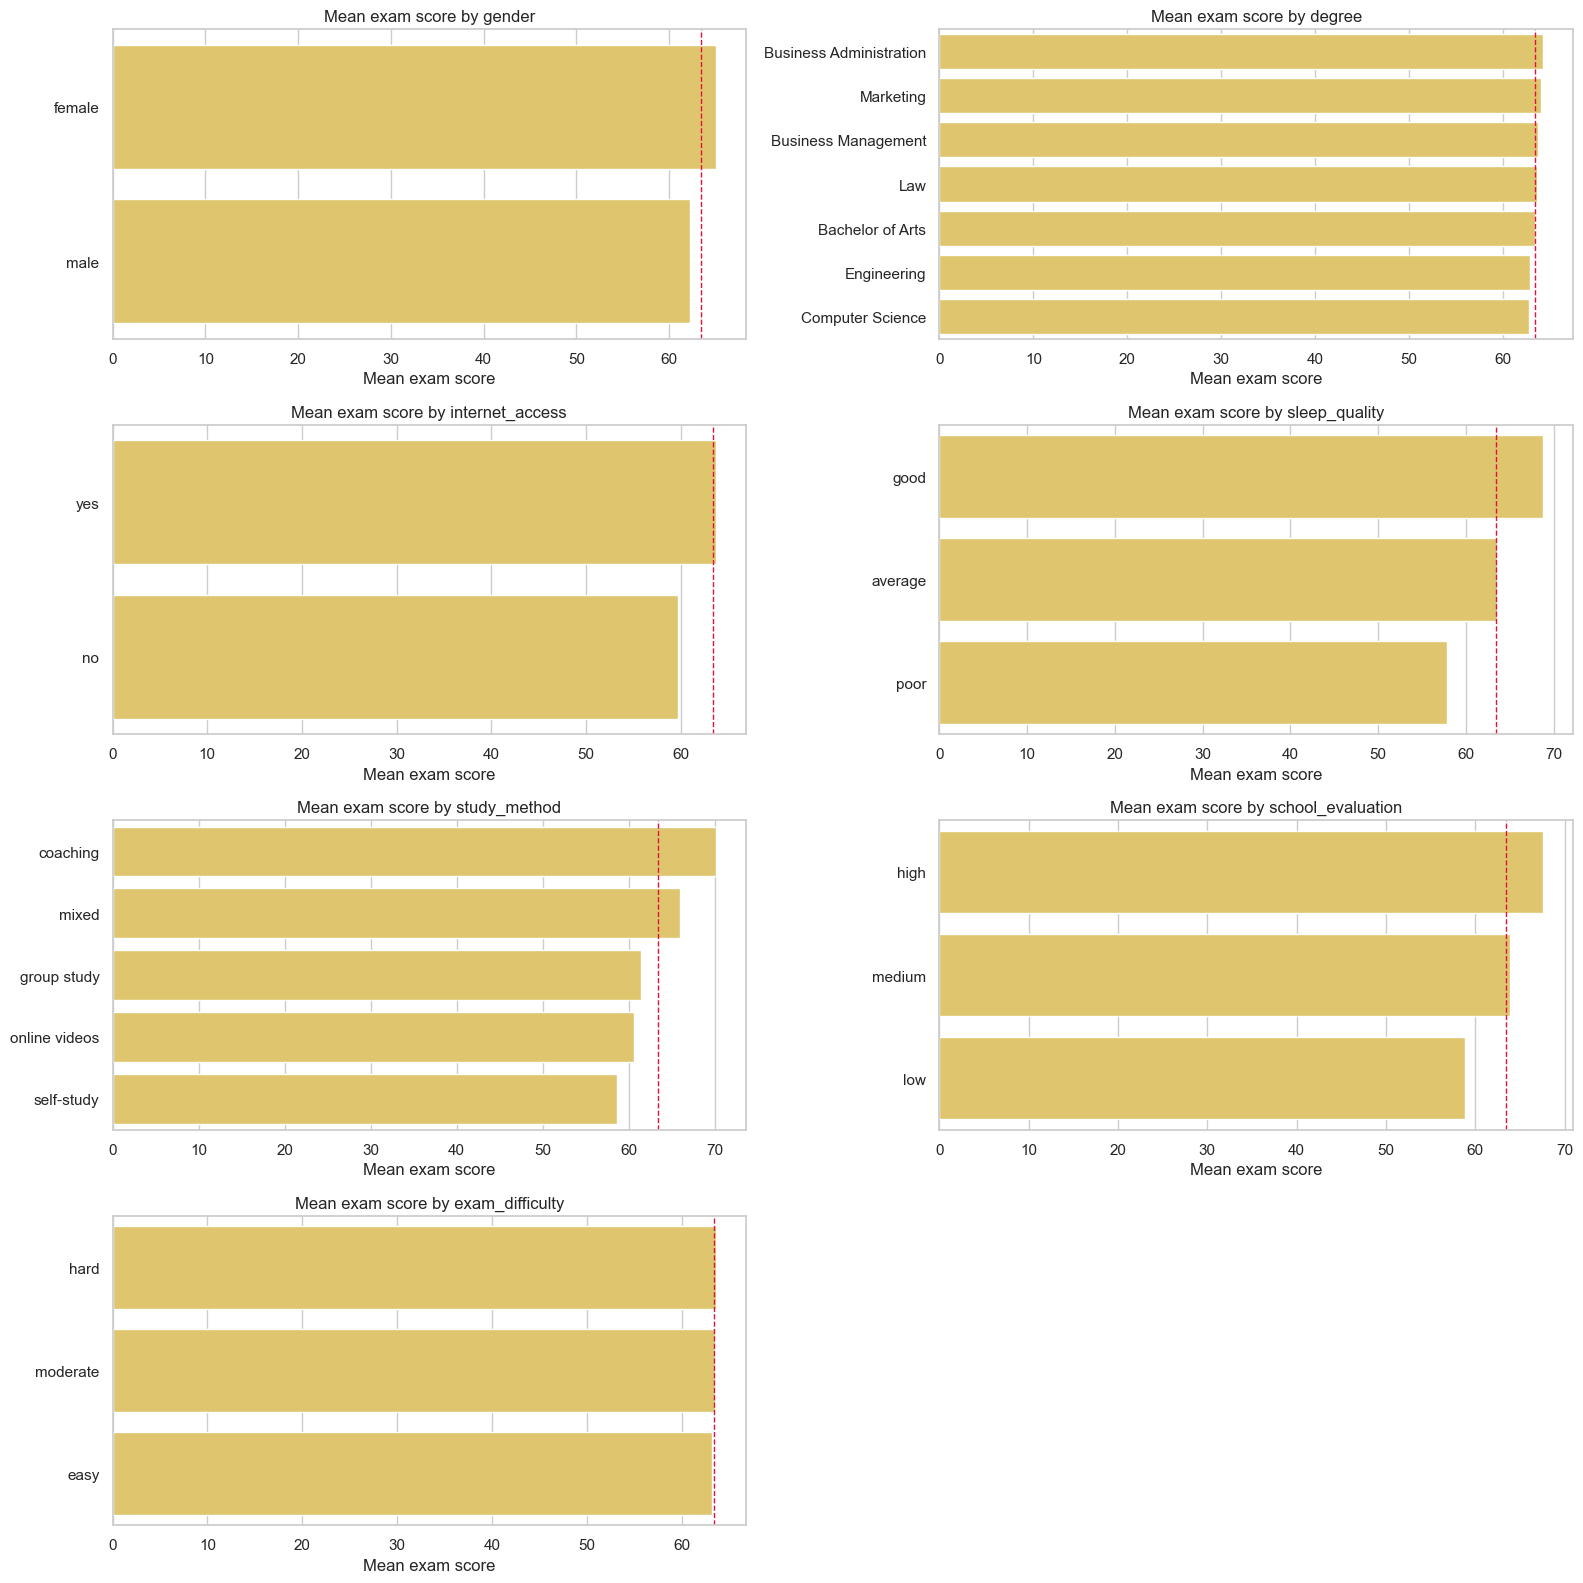

WindowsPath('outputs/part1/1_1_8_categorical_relationships/categorical_mean_scores.png')

In [ ]:
# Compare score distributions across categorical groups.
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.ravel()

for ax, col in zip(axes, categorical_features):
    means = (
        data.groupby(col, dropna=False)[target]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    sns.barplot(data=means, y=col, x=target, ax=ax, color="#f2cf5b")
    ax.axvline(data[target].mean(), color="crimson", linestyle="--", linewidth=1, label="Overall mean")
    ax.set_title(f"Mean exam score by {col}")
    ax.set_xlabel("Mean exam score")
    ax.set_ylabel("")

axes[-1].axis("off")
plt.tight_layout()
plt.show()
save_figure("categorical_mean_scores", folder="1_1_8_categorical_relationships", fig=fig)

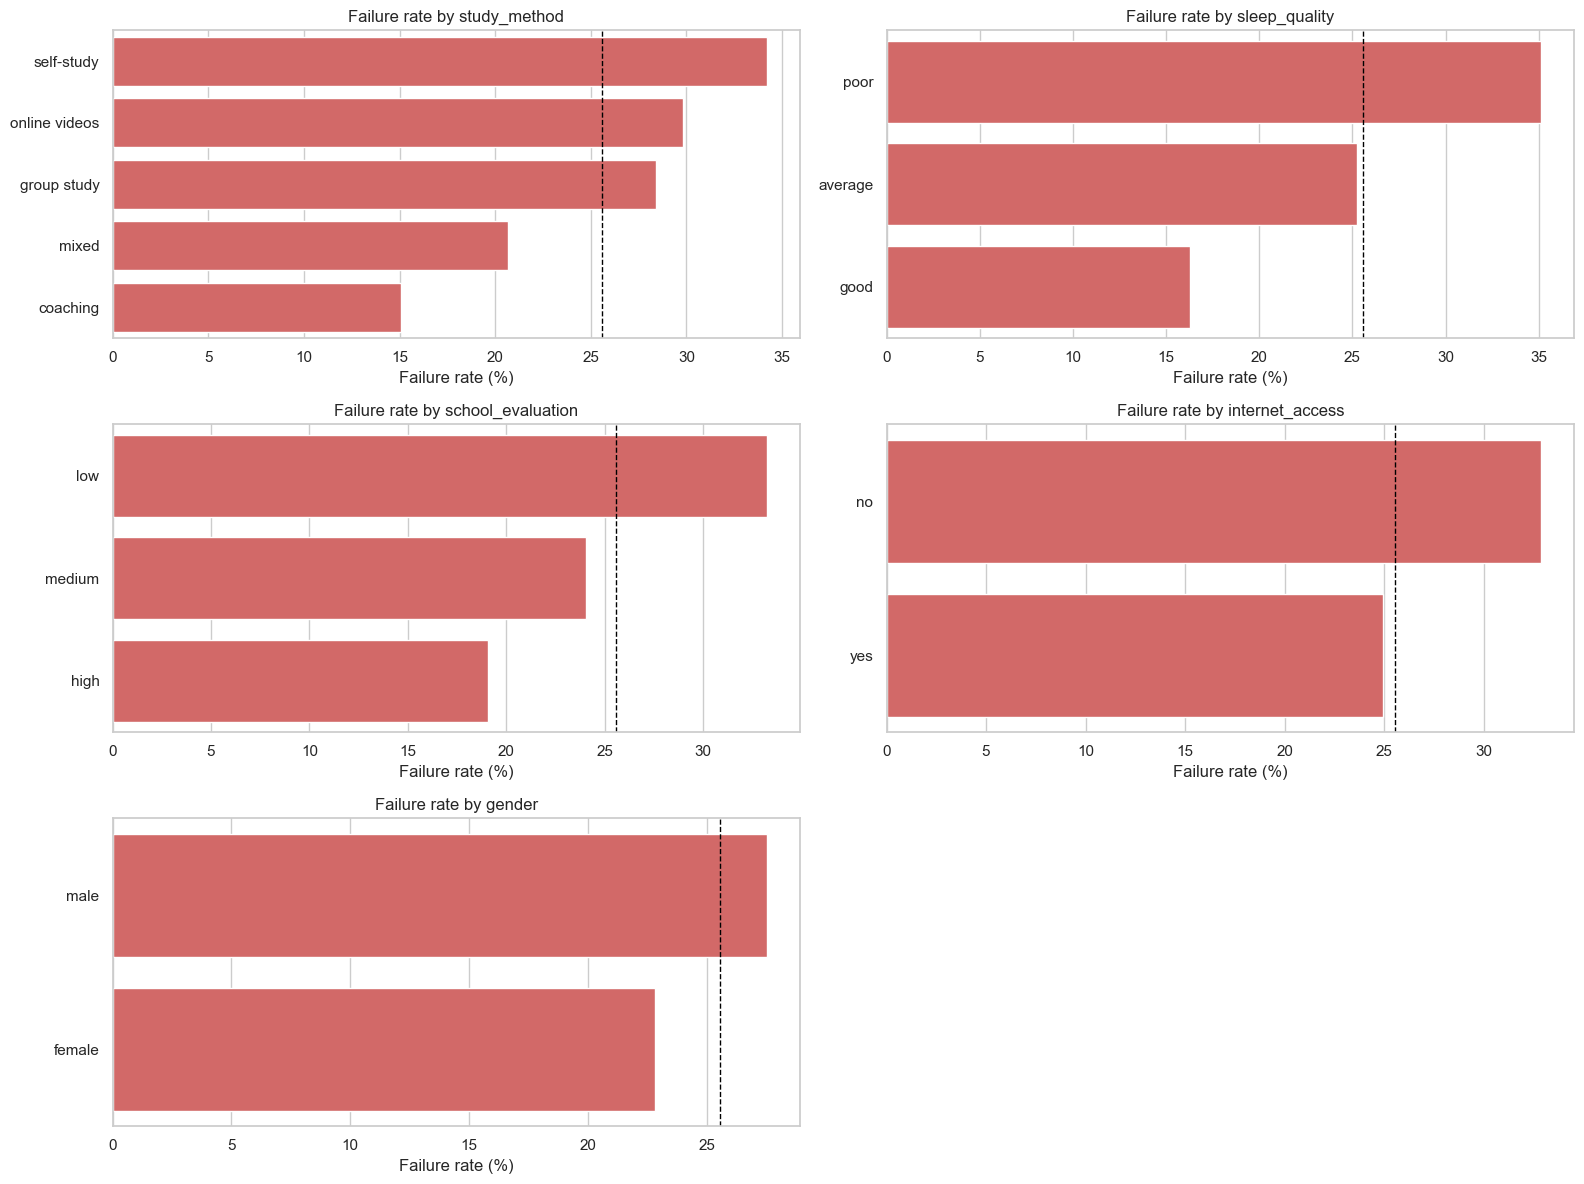

WindowsPath('outputs/part1/1_1_8_categorical_relationships/failure_rate_by_category.png')

In [ ]:
# Plot failure rates for the most relevant categorical features.
key_risk_features = ["study_method", "sleep_quality", "school_evaluation", "internet_access", "gender"]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.ravel()

for ax, col in zip(axes, key_risk_features):
    risk = (
        data.groupby(col, dropna=False)["is_at_risk"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name="failure_rate_pct")
    )
    sns.barplot(data=risk, y=col, x="failure_rate_pct", ax=ax, color="#e45756")
    ax.axvline(failure_rate * 100, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Failure rate by {col}")
    ax.set_xlabel("Failure rate (%)")
    ax.set_ylabel("")

axes[-1].axis("off")
plt.tight_layout()
plt.show()
save_figure("failure_rate_by_category", folder="1_1_8_categorical_relationships", fig=fig)

**Categorical observations.** The largest categorical gaps are found for `study_method`, `sleep_quality`, and `school_evaluation`. `degree` varies only slightly, and `exam_difficulty` appears weak in this dataset.


### 1.1.9 Exploratory Feature Importance

This first ranking is model-free:

- numerical variables are ranked by absolute correlation with `exam_score`;
- categorical variables are ranked by the gap between their highest and lowest group mean.

The goal is not to replace model-based importance, but to document which features look useful before training.


In [ ]:
# Combine numerical and categorical EDA signals into one ranking.
numerical_importance = (
    correlation_with_target.abs()
    .rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
    .assign(type="numerical_correlation_abs")
)

categorical_importance_rows = []
for col in categorical_features:
    means = data.groupby(col, dropna=False)[target].mean().sort_values()
    categorical_importance_rows.append({
        "feature": col,
        "importance": means.iloc[-1] - means.iloc[0],
        "type": "categorical_mean_range",
        "lowest_group": str(means.index[0]),
        "highest_group": str(means.index[-1]),
    })

categorical_importance = pd.DataFrame(categorical_importance_rows)

importance_table = pd.concat(
    [
        numerical_importance.assign(lowest_group=np.nan, highest_group=np.nan),
        categorical_importance,
    ],
    ignore_index=True,
).sort_values("importance", ascending=False)

save_table(importance_table.round(3), "eda_feature_importance", folder="1_1_9_feature_importance")
importance_table.round(3)

,feature,importance,type,lowest_group,highest_group
10,study_method,11.555,categorical_mean_range,self-study,coaching
9,sleep_quality,10.866,categorical_mean_range,poor,good
11,school_evaluation,8.703,categorical_mean_range,low,high
8,internet_access,3.988,categorical_mean_range,no,yes
6,gender,2.808,categorical_mean_range,male,female
7,degree,1.511,categorical_mean_range,Computer Science,Business Administration
0,study_hours,0.758,numerical_correlation_abs,NaN,NaN
12,exam_difficulty,0.449,categorical_mean_range,easy,hard
1,class_attendance,0.359,numerical_correlation_abs,NaN,NaN
2,sleep_hours,0.166,numerical_correlation_abs,NaN,NaN


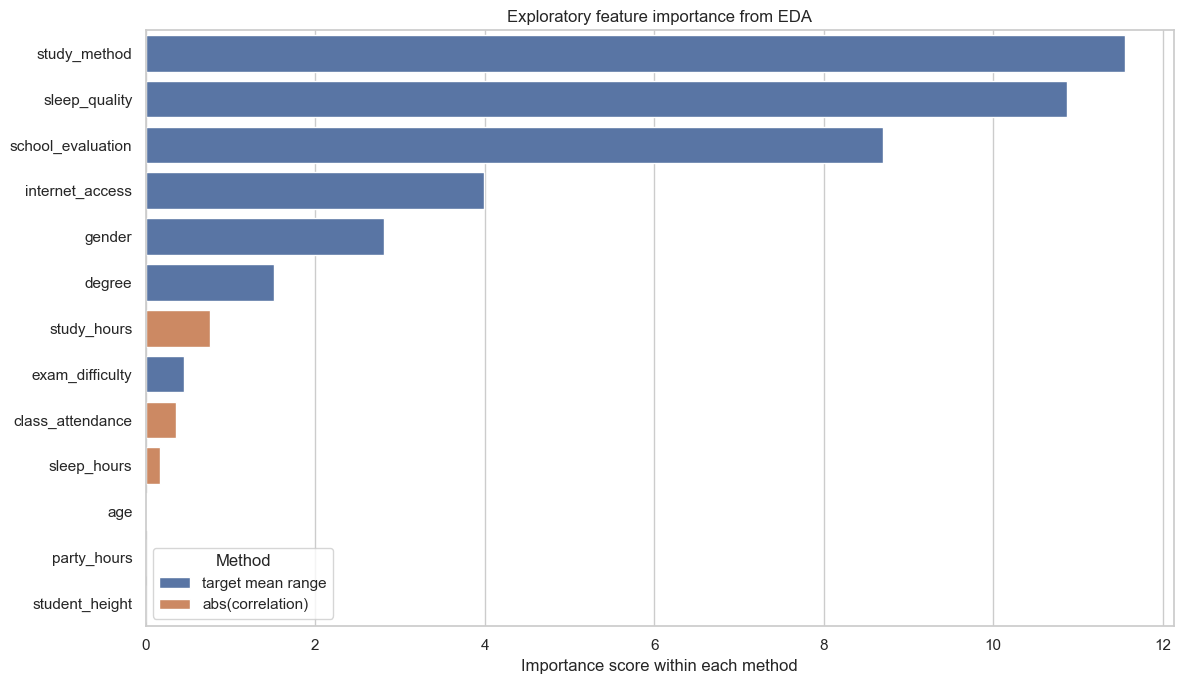

WindowsPath('outputs/part1/1_1_9_feature_importance/exploratory_feature_importance.png')

In [ ]:
# Plot the exploratory feature-importance ranking.
plot_importance = importance_table.copy()
plot_importance["importance_label"] = np.where(
    plot_importance["type"].eq("numerical_correlation_abs"),
    "abs(correlation)",
    "target mean range",
)

fig = plt.figure(figsize=(12, 7))
sns.barplot(data=plot_importance, x="importance", y="feature", hue="importance_label", dodge=False)
plt.title("Exploratory feature importance from EDA")
plt.xlabel("Importance score within each method")
plt.ylabel("")
plt.legend(title="Method")
plt.tight_layout()
plt.show()
save_figure("exploratory_feature_importance", folder="1_1_9_feature_importance", fig=fig)

**Importance observations.** The EDA points to `study_hours`, `class_attendance`, `sleep_hours`, `study_method`, `sleep_quality`, and `school_evaluation` as the most useful variables. `student_height`, `party_hours`, `age`, `degree`, and `exam_difficulty` appear weaker at this stage.


### 1.1.10 Outliers, Plausibility and Data Quality Notes


In [ ]:
# Check whether numerical ranges are plausible.
range_checks = pd.DataFrame({
    "min": data[numeric_features + [target]].min(),
    "max": data[numeric_features + [target]].max(),
    "mean": data[numeric_features + [target]].mean(),
    "median": data[numeric_features + [target]].median(),
}).round(3)

save_table(range_checks, "numeric_feature_ranges", folder="1_1_10_quality_checks")
range_checks

,min,max,mean,median
age,17.00,24.00,20.546,21.00
study_hours,0.08,7.91,4.003,4.01
class_attendance,40.60,99.40,71.987,72.60
sleep_hours,4.10,9.90,7.073,7.10
party_hours,0.00,19.00,4.001,4.00
student_height,1.48,2.03,1.755,1.75
exam_score,12.60,100.00,63.407,63.62


In [62]:
# Inspect observations at the score cap.
perfect_scores = data[data[target] == 100]

print(f"Rows with exam_score = 100: {len(perfect_scores):,}")
print(f"Share of dataset: {len(perfect_scores) / len(data):.2%}")

save_table(perfect_scores[numeric_features + [target]].describe().T.round(3), "perfect_score_summary", folder="1_1_10_quality_checks")
perfect_scores[["study_hours", "class_attendance", "sleep_hours", "study_method", "sleep_quality", target]].head(10)

Rows with exam_score = 100: 17,067
Share of dataset: 2.71%


,study_hours,class_attendance,sleep_hours,study_method,sleep_quality,exam_score
2,4.68,92.6,5.8,coaching,poor,100.0
4,7.65,86.9,9.6,self-study,good,100.0
12,7.40,92.4,8.2,coaching,average,100.0
52,6.66,85.4,5.5,coaching,poor,100.0
62,4.78,96.0,4.6,coaching,good,100.0
65,7.91,73.3,6.6,coaching,poor,100.0
170,5.61,94.0,7.7,coaching,good,100.0
181,7.71,99.4,8.8,coaching,good,100.0
191,6.05,93.1,6.8,coaching,poor,100.0
275,7.80,80.0,9.3,mixed,good,100.0


**Data-quality observations.** Most ranges are plausible. The target cap at 100 should be kept in mind because models may underpredict very high scores. `student_height` is likely unrelated to academic performance and may add noise.


### 1.1.11 Known Limitations and Data Quality Notes

This table records the main limits of the dataset and their likely impact on modelling. It is useful later when interpreting the results.


**Main limitations.** The dataset contains a ceiling effect, informative missing values and an imbalanced failure group. These points should be reflected in preprocessing, evaluation and the final discussion.


In [ ]:
# Store the main data-quality limitations as a report-ready table.
limitations = [
    {
        'limitation': 'Ceiling effect at score = 100',
        'description': f'{len(perfect_scores):,} observations ({len(perfect_scores)/len(data)*100:.1f}%) are capped at 100.',
        'impact': 'Models may underpredict very strong students. Evaluation should track errors in the [90, 100] range.',
        'mitigation': 'Use separate metrics for top performers; consider top-coded loss functions.'
    },
    {
        'limitation': 'Missing values in key variables',
        'description': 'About 3% of study_hours, 7% of study_method, and 10% of internet_access are missing.',
        'impact': 'Imputation alone may bias estimates. Missingness indicators should be retained.',
        'mitigation': 'Include "X_missing" binary flags; avoid simple deletion.'
    },
    {
        'limitation': 'Imbalanced failure threshold',
        'description': f'{(data["is_at_risk"].sum()/len(data)*100):.1f}% of students are below threshold 50.',
        'impact': 'Minority class harder to predict accurately. Recall for at-risk students is critical.',
        'mitigation': 'Use stratified CV; monitor precision-recall trade-off; consider class weights.'
    },
    {
        'limitation': 'Potential gender bias',
        'description': f'Gender groups show mean score differences (see fairness section).',
        'impact': 'Models may encode or amplify disparities. Non-binding on model choice but requires monitoring.',
        'mitigation': 'Regular fairness audits; consider fairness-aware algorithms if disparities are large.'
    },
    {
        'limitation': 'No temporal information',
        'description': 'Data is cross-sectional; no time series or longitudinal patterns.',
        'impact': 'Cannot model student trajectories or within-semester trends.',
        'mitigation': 'Collect/request time-stamped data for future analysis.'
    },
    {
        'limitation': 'Potential data leakage via exam_difficulty or school_evaluation',
        'description': 'These variables may reflect exam performance rather than precede it.',
        'impact': 'High correlations might not generalize to new exams with different difficulty.',
        'mitigation': 'Treat as "do not use in production" unless causality is confirmed with experts.'
    },
    {
        'limitation': 'student_height is implausible',
        'description': 'No educational rationale; near-zero correlation with score.',
        'impact': 'Inclusion adds noise and increases overfitting risk.',
        'mitigation': 'Drop feature; request clarification on data collection.'
    },
    {
        'limitation': 'Sample size and representativeness',
        'description': f'Dataset has {len(data):,} observations but geographic/temporal scope unclear.',
        'impact': 'Model performance may not generalize to new schools or time periods.',
        'mitigation': 'Stratified test set; hold-out validation; external evaluation recommended.'
    }
]

limitations_df = pd.DataFrame(limitations)
for idx, row in limitations_df.iterrows():
    print(f"\n{'='*80}")
    print(f"Limitation {idx+1}: {row['limitation']}")
    print(f"{'='*80}")
    print(f"Description: {row['description']}")
    print(f"Impact: {row['impact']}")
    print(f"Mitigation: {row['mitigation']}")


Limitation 1: Ceiling effect at score = 100
Description: 17,067 observations (2.7%) are capped at 100.
Impact: Models may underpredict very strong students. Evaluation should track errors in the [90, 100] range.
Mitigation: Use separate metrics for top performers; consider top-coded loss functions.

Limitation 2: Missing values in key variables
Description: About 3% of study_hours, 7% of study_method, and 10% of internet_access are missing.
Impact: Imputation alone may bias estimates. Missingness indicators should be retained.
Mitigation: Include "X_missing" binary flags; avoid simple deletion.

Limitation 3: Imbalanced failure threshold
Description: 25.6% of students are below threshold 50.
Impact: Minority class harder to predict accurately. Recall for at-risk students is critical.
Mitigation: Use stratified CV; monitor precision-recall trade-off; consider class weights.

Limitation 4: Potential gender bias
Description: Gender groups show mean score differences (see fairness section

### 1.1.12 Multicollinearity Check: Variance Inflation Factor

Variance Inflation Factor (VIF) is used to check whether numerical predictors can be explained by other predictors. High VIF values indicate that linear-model coefficients should be interpreted carefully.


Variance Inflation Factor (VIF) for Numerical Features:
            feature    R2   VIF
1       study_hours  0.01  1.01
2  class_attendance  0.01  1.01
3       sleep_hours  0.00  1.00
0               age  0.00  1.00
5    student_height  0.00  1.00
4       party_hours  0.00  1.00

Interpretation:
  VIF = 1: No correlation with other features (ideal)
  VIF < 5: Generally acceptable
  VIF >= 5-10: Concerning; consider removing or combining features
  VIF > 10: Severe multicollinearity; requires action

No severe multicollinearity detected


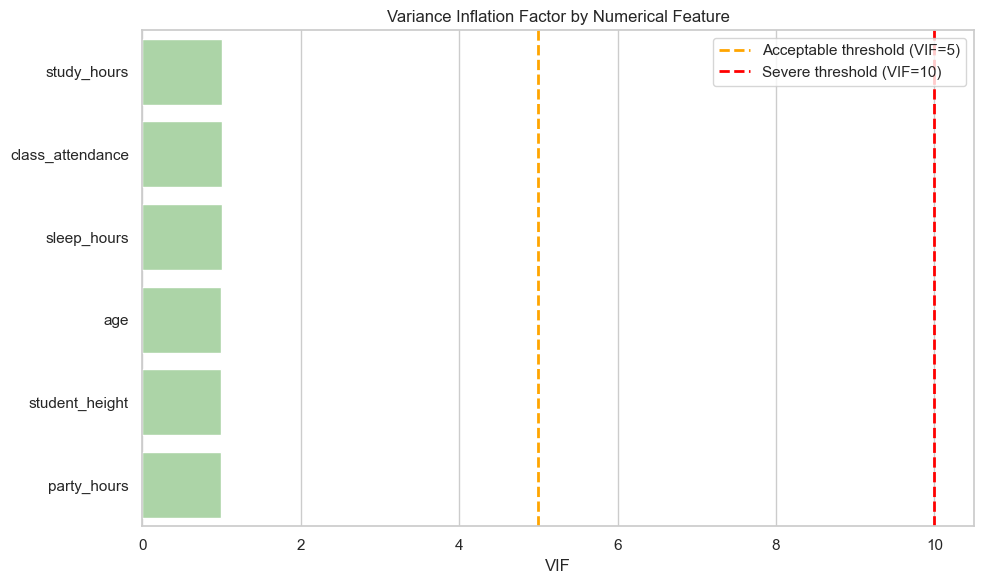

WindowsPath('outputs/part1/1_1_11_limitations_checks/vif_barplot.png')

<Figure size 1000x500 with 0 Axes>

In [32]:
from sklearn.linear_model import LinearRegression

# Prepare numerical features with median imputation.
X_vif = data[numeric_features].fillna(data[numeric_features].median()).copy()

# Calculate VIF for each feature.
vif_rows = []
for feature in X_vif.columns:
    X_other = X_vif.drop(columns=[feature])
    y_feature = X_vif[feature]
    vif_model = LinearRegression().fit(X_other, y_feature)
    r2 = vif_model.score(X_other, y_feature)
    vif = np.inf if r2 >= 1 else 1.0 / (1.0 - r2)
    vif_rows.append({
        'feature': feature,
        'R2': r2,
        'VIF': vif,
    })

vif_data = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)

print("Variance Inflation Factor (VIF) for Numerical Features:")
print(vif_data.round(2))
print("\nInterpretation:")
print("  VIF = 1: No correlation with other features (ideal)")
print("  VIF < 5: Generally acceptable")
print("  VIF >= 5-10: Concerning; consider removing or combining features")
print("  VIF > 10: Severe multicollinearity; requires action")

high_vif_features = vif_data[vif_data['VIF'] > 5]['feature'].tolist()
if high_vif_features:
    print(f"\nHigh VIF features to consider: {high_vif_features}")
else:
    print("\nNo severe multicollinearity detected")

plt.figure(figsize=(10, 6))
sns.barplot(data=vif_data, x='VIF', y='feature', color='#a6dba0')
plt.axvline(5, color='orange', linestyle='--', linewidth=2, label='Acceptable threshold (VIF=5)')
plt.axvline(10, color='red', linestyle='--', linewidth=2, label='Severe threshold (VIF=10)')
plt.title('Variance Inflation Factor by Numerical Feature')
plt.xlabel('VIF')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()
save_figure("vif_barplot", folder="1_1_11_limitations_checks", fig=plt.gcf())

In [33]:
# Keep this cell runnable on its own.
# Repeat the VIF setup to avoid hidden state.
from sklearn.linear_model import LinearRegression

X_vif = data[numeric_features].fillna(data[numeric_features].median()).copy()

vif_rows = []
for feature in X_vif.columns:
    X_other = X_vif.drop(columns=[feature])
    y_feature = X_vif[feature]
    vif_model = LinearRegression().fit(X_other, y_feature)
    r2 = vif_model.score(X_other, y_feature)
    vif = np.inf if r2 >= 1 else 1.0 / (1.0 - r2)
    vif_rows.append({
        'feature': feature,
        'R2': r2,
        'VIF': vif,
    })

vif_data = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
save_table(vif_data.round(2), "vif_summary", folder="1_1_11_limitations_checks")

print("Variance Inflation Factor (VIF) for Numerical Features:")
print(vif_data.round(2))
print("\nInterpretation:")
print("  VIF = 1: No correlation with other features (ideal)")
print("  VIF < 5: Generally acceptable")
print("  VIF >= 5-10: Concerning; consider removing or combining features")
print("  VIF > 10: Severe multicollinearity; requires action")

high_vif_features = vif_data[vif_data['VIF'] > 5]['feature'].tolist()
if high_vif_features:
    print(f"\nHigh VIF features to consider: {high_vif_features}")
else:
    print("\nNo severe multicollinearity detected")

Variance Inflation Factor (VIF) for Numerical Features:
            feature    R2   VIF
1       study_hours  0.01  1.01
2  class_attendance  0.01  1.01
3       sleep_hours  0.00  1.00
0               age  0.00  1.00
5    student_height  0.00  1.00
4       party_hours  0.00  1.00

Interpretation:
  VIF = 1: No correlation with other features (ideal)
  VIF < 5: Generally acceptable
  VIF >= 5-10: Concerning; consider removing or combining features
  VIF > 10: Severe multicollinearity; requires action

No severe multicollinearity detected


**Multicollinearity observations.** Some educational variables are naturally correlated because they describe related behaviours. This matters mostly for linear models, where coefficients can become unstable. Tree-based models are less sensitive to this issue.


### 1.1.13 Fairness and Bias Analysis: Gender

The project includes `gender`, so I inspect whether score and failure rate differ between groups. This is only a first diagnostic; it does not replace a full fairness audit.


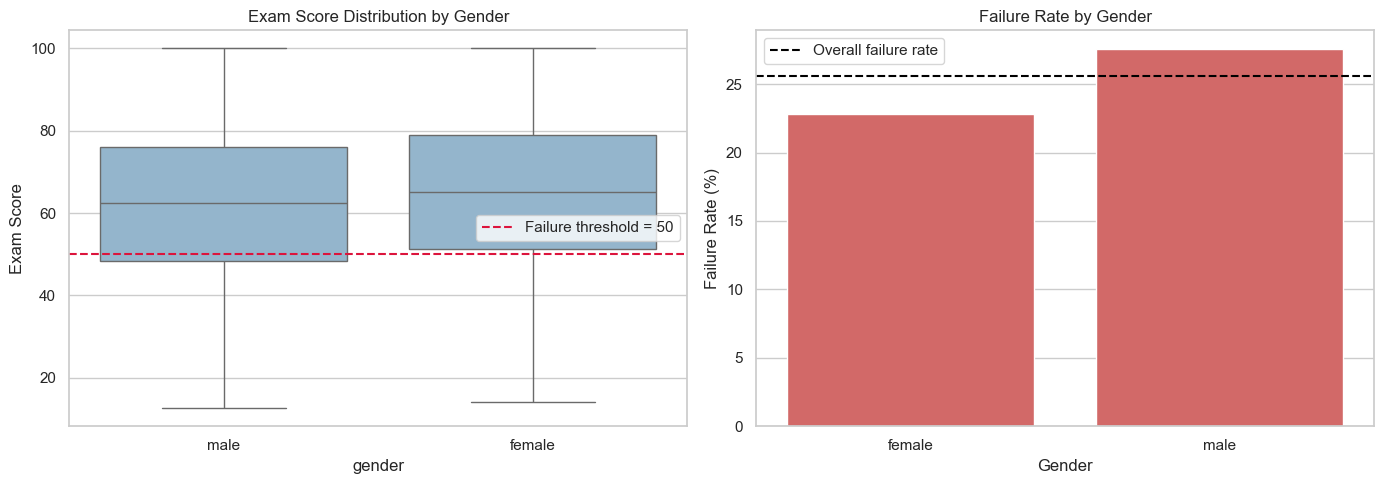

WindowsPath('outputs/part1/1_1_12_multicollinearity_analysis/gender_fairness_analysis.png')

In [ ]:
# Visualise first-order gender differences in score and failure rate.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution by gender.
sns.boxplot(data=data.dropna(subset=['gender']), x='gender', y=target, ax=axes[0], color='#8ab6d6')
axes[0].axhline(failure_threshold, color='crimson', linestyle='--', label=f'Failure threshold = {failure_threshold}')
axes[0].set_title('Exam Score Distribution by Gender')
axes[0].set_ylabel('Exam Score')
axes[0].legend()

# Failure rate by gender.
failure_by_gender = data.dropna(subset=['gender']).groupby('gender')['is_at_risk'].apply(lambda x: x.sum() / len(x) * 100)
sns.barplot(x=failure_by_gender.index, y=failure_by_gender.values, ax=axes[1], color='#e45756')
axes[1].axhline(failure_rate * 100, color='black', linestyle='--', label='Overall failure rate')
axes[1].set_title('Failure Rate by Gender')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_xlabel('Gender')
axes[1].legend()

plt.tight_layout()
plt.show()
save_figure("gender_fairness_analysis", folder="1_1_12_multicollinearity_analysis", fig=fig)     

In [ ]:
# Compute group-level fairness diagnostics for gender.
gender_fairness = []

for gender_val in data['gender'].dropna().unique():
    subset = data[data['gender'] == gender_val]
    
    gender_fairness.append({
        'gender': gender_val,
        'count': len(subset),
        'mean_score': subset[target].mean(),
        'median_score': subset[target].median(),
        'failure_rate': (subset['is_at_risk'].sum() / len(subset) * 100),
        'std_score': subset[target].std(),
    })

fairness_df = pd.DataFrame(gender_fairness)
print("Fairness Analysis by Gender:")
print(fairness_df.round(2))
save_table(fairness_df.round(2), "gender_fairness_analysis", folder="1_1_12_multicollinearity_analysis")

# Test whether group means differ.
from scipy.stats import ttest_ind, f_oneway

gender_groups = [group[target].values for name, group in data.groupby('gender', dropna=True)]
if len(gender_groups) >= 2:
    f_stat, p_value = f_oneway(*gender_groups)
    print(f"\nANOVA Test for mean score differences across gender groups:")
    print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("Statistically significant difference detected (p < 0.05)")
    else:
        print("No statistically significant difference (p >= 0.05)")

Fairness Analysis by Gender:
   gender   count  mean_score  median_score  failure_rate  std_score
0    male  365662       62.23         62.40         27.55      19.00
1  female  264338       65.04         65.17         22.83      18.77

ANOVA Test for mean score differences across gender groups:
F-statistic: 3386.3968, p-value: 0.000000
Statistically significant difference detected (p < 0.05)


**Fairness observations.** `gender` is sensitive. Differences in average score or failure rate do not prove unfairness, but they show that this variable should be handled with care before any real deployment.


### 1.1.14 Exploratory Feature Importance: Mutual Information

Correlation captures linear relationships. Mutual information adds a second view by detecting more general dependencies between each feature and the target.


In [ ]:
# Estimate non-linear feature relevance with mutual information.
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mutual_info_score

# Mutual information for numerical features.
X_numeric = data[numeric_features].fillna(data[numeric_features].median())
mi_regression = mutual_info_regression(X_numeric, data[target], random_state=RANDOM_STATE)
mi_numeric = pd.DataFrame({
    'feature': numeric_features,
    'MI_regression': mi_regression,
}).sort_values('MI_regression', ascending=False)

# Mutual information for categorical features.
y_risk = data['is_at_risk'].astype(int)
mi_categorical_rows = []
for feature in categorical_features:
    x_col = data[feature].fillna('Unknown').astype(str)
    mi_categorical_rows.append({
        'feature': feature,
        'MI_classification': mutual_info_score(x_col, y_risk),
    })

mi_categorical = pd.DataFrame(mi_categorical_rows).sort_values('MI_classification', ascending=False)

print("Mutual Information - Numerical Features:")
print(mi_numeric.round(4))
print("\nMutual Information - Categorical Features:")
print(mi_categorical.round(4))

comparison_table = mi_numeric.merge(
    correlation_with_target.abs().rename('abs_correlation').reset_index().rename(columns={'index': 'feature'}),
    on='feature',
    how='outer',
).fillna(0)

save_table(mi_numeric.round(4), "mutual_information_numerical", folder="1_1_13_fairness_analysis")
save_table(mi_categorical.round(4), "mutual_information_categorical", folder="1_1_13_fairness_analysis")
save_table(comparison_table.round(4), "mi_vs_correlation_comparison", folder="1_1_13_fairness_analysis")

print("\nComparison: MI vs Absolute Correlation (numerical features only):")
print(comparison_table.sort_values('MI_regression', ascending=False).round(4))

Mutual Information - Numerical Features:
            feature  MI_regression
1       study_hours         0.6404
2  class_attendance         0.1832
3       sleep_hours         0.0429
0               age         0.0073
4       party_hours         0.0000
5    student_height         0.0000

Mutual Information - Categorical Features:
             feature  MI_classification
3      sleep_quality             0.0160
4       study_method             0.0123
5  school_evaluation             0.0089
0             gender             0.0014
2    internet_access             0.0011
1             degree             0.0003
6    exam_difficulty             0.0000

Comparison: MI vs Absolute Correlation (numerical features only):
            feature  MI_regression  abs_correlation
5       study_hours         0.6404           0.7576
1  class_attendance         0.1832           0.3595
3       sleep_hours         0.0429           0.1659
0               age         0.0073           0.0100
2       party_hours    

**Mutual-information observations.** Mutual information can reveal non-linear relationships that simple correlation misses. This is useful for variables such as `sleep_hours`, where the effect may not be purely linear.


### 1.1.15 Baseline Model Performance

A baseline sets the minimum useful performance level. For score prediction, the simplest baseline is to always predict the average training score.


In [ ]:
# Compute simple baselines before fitting real models.
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Baseline 1: predict the mean score.
baseline_mean_pred = np.full(len(data), data[target].mean())
baseline_mae_mean = mean_absolute_error(data[target], baseline_mean_pred)
baseline_rmse_mean = np.sqrt(mean_squared_error(data[target], baseline_mean_pred))

# Baseline 2: threshold-aware reference using the observed risk group.
baseline_risk_aware_pred = np.where(
    data[target] < failure_threshold,
    failure_threshold,
    data[target].mean(),
)
baseline_mae_risk = mean_absolute_error(data[target], baseline_risk_aware_pred)
baseline_rmse_risk = np.sqrt(mean_squared_error(data[target], baseline_risk_aware_pred))

baseline_table = pd.DataFrame({
    'baseline_model': ['Simple mean', 'Risk-aware threshold'],
    'MAE': [baseline_mae_mean, baseline_mae_risk],
    'RMSE': [baseline_rmse_mean, baseline_rmse_risk],
})

save_table(baseline_table.round(3), "baseline_results", folder="1_1_14_baseline_models")

print("Baseline model performance (on full dataset):")
print(baseline_table.round(3))
print(f"\nInterpretation: A model must achieve MAE < {baseline_mae_mean:.2f} to beat the simple mean baseline.")

Baseline model performance (on full dataset):
         baseline_model     MAE    RMSE
0           Simple mean  15.594  18.951
1  Risk-aware threshold  12.166  15.426

Interpretation: A model must achieve MAE < 15.59 to beat the simple mean baseline.


**Baseline observations.** A simple mean predictor gives a first score to beat. Any model used by the school should clearly improve on this baseline, otherwise the extra complexity is not justified.


### 1.1.16 Consequences for Preprocessing and Modelling

The EDA leads to the following modelling choices:

1. remove `id`, since it is only an identifier;
2. impute missing numerical values and keep missingness indicators;
3. impute missing categorical values with an explicit `Unknown` category;
4. one-hot encode categorical variables;
5. scale numerical variables for models that need comparable feature scales;
6. monitor both regression error and the ability to detect students below 50.


### 1.1.17 Final EDA Conclusions

The dataset is suitable for modelling, but it is not perfectly neutral or clean. Missingness carries information, the failure group is a minority, and some variables are much more predictive than others.

The strongest signals are educational and behavioural: study time, attendance, sleep, study method and school evaluation. Evaluation should therefore combine standard regression metrics with risk-oriented metrics around the threshold of 50.


## 1.2 Feature Selection and Creation

This section turns the EDA into a modelling feature set. The goal is to keep variables supported by data or domain logic, and to add only simple features that remain interpretable.


### 1.2.1 Feature Selection Strategy


In [ ]:
# Select features supported by EDA and domain logic.
strong_features = [
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "study_method",
    "sleep_quality",
    "school_evaluation",
]

candidate_features = [
    "internet_access",
    "gender",          # keep initially, then evaluate bias/fairness later
    "degree",
    "exam_difficulty",
    "age",
]

dropped_features = [
    "id",              # identifier, not a student characteristic
    "student_height",  # no educational meaning and near-zero relation with target
    "party_hours",     # near-zero relation in this dataset
]

selected_original_features = strong_features + candidate_features

feature_selection_summary = pd.DataFrame({
    "feature_group": ["strong"] * len(strong_features)
    + ["candidate"] * len(candidate_features)
    + ["dropped"] * len(dropped_features),
    "feature": strong_features + candidate_features + dropped_features,
})

save_table(feature_selection_summary, "feature_selection_summary", folder="1_2_1_feature_selection")
feature_selection_summary

,feature_group,feature
0,strong,study_hours
1,strong,class_attendance
2,strong,sleep_hours
3,strong,study_method
4,strong,sleep_quality
5,strong,school_evaluation
6,candidate,internet_access
7,candidate,gender
8,candidate,degree
9,candidate,exam_difficulty


### 1.2.2 Justification of Selected and Dropped Features


In [ ]:
# Document the keep/drop decision for each original feature.
feature_notes = pd.DataFrame([
    ["study_hours", "selected", "Strongest numerical relationship with exam_score."],
    ["class_attendance", "selected", "Meaningful positive relationship and strong domain logic."],
    ["sleep_hours", "selected", "Moderate positive relationship; useful wellbeing indicator."],
    ["study_method", "selected", "Large target mean differences between categories."],
    ["sleep_quality", "selected", "Large target mean differences and complements sleep_hours."],
    ["school_evaluation", "selected", "Clear categorical target gap; may reflect academic context."],
    ["internet_access", "candidate", "Modest relationship and useful for study resources; has missing values."],
    ["gender", "candidate", "Predictive gap exists, but it is sensitive and must be checked for bias."],
    ["degree", "candidate", "Small signal, but can capture curriculum differences."],
    ["exam_difficulty", "candidate", "Weak in EDA but conceptually linked to scores."],
    ["age", "candidate", "Weak correlation, retained initially to test whether models use it."],
    ["id", "dropped", "Identifier only; keeping it risks learning row order or noise."],
    ["student_height", "dropped", "No educational justification and near-zero relation with the score."],
    ["party_hours", "dropped", "Near-zero observed relationship; can be re-tested later as sensitivity analysis."],
], columns=["feature", "decision", "reason"])

save_table(feature_notes, "feature_selection_notes", folder="1_2_2_justification_of_feature_selection_decisions")  
feature_notes

,feature,decision,reason
0,study_hours,selected,Strongest numerical relationship with exam_score.
1,class_attendance,selected,Meaningful positive relationship and strong do...
2,sleep_hours,selected,Moderate positive relationship; useful wellbei...
3,study_method,selected,Large target mean differences between categories.
4,sleep_quality,selected,Large target mean differences and complements ...
5,school_evaluation,selected,Clear categorical target gap; may reflect acad...
6,internet_access,candidate,Modest relationship and useful for study resou...
7,gender,candidate,"Predictive gap exists, but it is sensitive and..."
8,degree,candidate,"Small signal, but can capture curriculum diffe..."
9,exam_difficulty,candidate,Weak in EDA but conceptually linked to scores.


### 1.2.3 Feature Creation

The created features are intentionally simple. They encode missingness, combine study effort with attendance, and represent sleep regularity.


In [ ]:
# Create interpretable features from missingness and study behaviour.
modeling_data = data.copy()

# Missingness indicators.
modeling_data["study_hours_missing"] = modeling_data["study_hours"].isna().astype(int)
modeling_data["internet_access_missing"] = modeling_data["internet_access"].isna().astype(int)
modeling_data["study_method_missing"] = modeling_data["study_method"].isna().astype(int)

# Study-effort interaction.
modeling_data["study_attendance_score"] = (
    modeling_data["study_hours"] * modeling_data["class_attendance"] / 100
)

# Sleep regularity proxy.
modeling_data["sleep_distance_from_8h"] = (modeling_data["sleep_hours"] - 8).abs()

# Low-study and low-attendance profile.
study_median = modeling_data["study_hours"].median()
attendance_median = modeling_data["class_attendance"].median()
modeling_data["low_study_low_attendance"] = (
    (modeling_data["study_hours"] < study_median)
    & (modeling_data["class_attendance"] < attendance_median)
).astype(int)

created_features = [
    "study_hours_missing",
    "internet_access_missing",
    "study_method_missing",
    "study_attendance_score",
    "sleep_distance_from_8h",
    "low_study_low_attendance",
]

save_table(modeling_data[created_features], "created_features", folder="1_2_3_feature_creation")
modeling_data[created_features].head()

,study_hours_missing,internet_access_missing,study_method_missing,study_attendance_score,sleep_distance_from_8h,low_study_low_attendance
0,0,1,0,7.81508,3.1,0
1,0,0,0,4.69260,3.3,0
2,0,1,0,4.33368,2.2,0
3,0,0,0,0.99000,0.3,1
4,0,0,0,6.64785,1.6,0


In [ ]:
# Measure how the created features relate to the target.
created_feature_summary = modeling_data[created_features + [target]].corr(numeric_only=True)[target]
save_table(created_feature_summary.drop(target).sort_values(key=lambda s: s.abs(), ascending=False).to_frame("correlation_with_exam_score"), "created_feature_correlations", folder="1_2_3_feature_creation")
created_feature_summary.drop(target).sort_values(key=lambda s: s.abs(), ascending=False).to_frame(
    "correlation_with_exam_score"
)

,correlation_with_exam_score
study_attendance_score,0.791768
low_study_low_attendance,-0.541720
sleep_distance_from_8h,-0.123341
study_method_missing,0.001240
study_hours_missing,-0.000838
internet_access_missing,0.000348


## 1.3 Data Pre-processing

The preprocessing is fitted after the train-validation split to avoid leakage. Numerical values are imputed and scaled; categorical values are imputed and one-hot encoded.


### 1.3.1 Define X and y


In [ ]:
# Build the modelling matrix from selected and created features.
selected_features = selected_original_features + created_features

X = modeling_data[selected_features].copy()
y = modeling_data[target].copy()

save_table(X.head(), "modeling_data_sample", folder="1_2_3_feature_creation")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
X.head()

X shape: (630000, 17)
y shape: (630000,)


,study_hours,class_attendance,sleep_hours,study_method,sleep_quality,school_evaluation,internet_access,gender,degree,exam_difficulty,age,study_hours_missing,internet_access_missing,study_method_missing,study_attendance_score,sleep_distance_from_8h,low_study_low_attendance
0,7.91,98.8,4.9,online videos,average,low,NaN,male,Computer Science,easy,21,0,1,0,7.81508,3.1,0
1,4.95,94.8,4.7,self-study,poor,medium,yes,female,Law,moderate,18,0,0,0,4.69260,3.3,0
2,4.68,92.6,5.8,coaching,poor,high,NaN,female,Computer Science,moderate,20,0,1,0,4.33368,2.2,0
3,2.00,49.5,8.3,group study,average,high,yes,male,Computer Science,moderate,19,0,0,0,0.99000,0.3,1
4,7.65,86.9,9.6,self-study,good,high,yes,female,Business Management,easy,23,0,0,0,6.64785,1.6,0


In [ ]:
# Separate numerical and categorical columns for preprocessing.
numerical_features_for_model = X.select_dtypes(exclude="object").columns.tolist()
categorical_features_for_model = X.select_dtypes(include="object").columns.tolist()

print("Numerical features:")
print(numerical_features_for_model)

print("\nCategorical features:")
print(categorical_features_for_model)

Numerical features:
['study_hours', 'class_attendance', 'sleep_hours', 'age', 'study_hours_missing', 'internet_access_missing', 'study_method_missing', 'study_attendance_score', 'sleep_distance_from_8h', 'low_study_low_attendance']

Categorical features:
['study_method', 'sleep_quality', 'school_evaluation', 'internet_access', 'gender', 'degree', 'exam_difficulty']


### 1.3.2 Train/Validation Split

The split is done before any imputation, encoding or scaling. This prevents validation information from influencing the preprocessing statistics learned from training data.


In [ ]:
# Create a reproducible train-validation split before preprocessing.
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Validation rows: {X_valid.shape[0]:,}")

Training rows: 504,000
Validation rows: 126,000


### 1.3.3 Preprocessing Pipeline

Numerical variables are median-imputed and scaled. Categorical variables are imputed with `Unknown` and one-hot encoded.


In [ ]:
# Define separate preprocessing pipelines by variable type.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", one_hot_encoder),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features_for_model),
    ("cat", categorical_transformer, categorical_features_for_model),
])

save_model(preprocessor, "preprocessor_pipeline", folder="1_3_3_preprocessing")
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [ ]:
# Fit preprocessing only on training data, then transform both splits.
X_train_prepared = preprocessor.fit_transform(X_train)
X_valid_prepared = preprocessor.transform(X_valid)

print(f"Prepared training shape: {X_train_prepared.shape}")
print(f"Prepared validation shape: {X_valid_prepared.shape}")

Prepared training shape: (504000, 37)
Prepared validation shape: (126000, 37)


### 1.3.4 Baseline Prepared for Model Comparison

The project asks for a simple baseline. For this regression task, the baseline predicts the mean training score for every observation.


In [ ]:
# Evaluate the mean baseline on the validation split.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_predictions = np.full(shape=len(y_valid), fill_value=y_train.mean())

baseline_results = pd.DataFrame({
    "model": ["mean_baseline"],
    "MAE": [mean_absolute_error(y_valid, baseline_predictions)],
    "RMSE": [np.sqrt(mean_squared_error(y_valid, baseline_predictions))],
    "R2": [r2_score(y_valid, baseline_predictions)],
})

save_table(baseline_results.round(3), "baseline_performance", folder="1_3_4_baseline_evaluation")
baseline_results.round(3)

,model,MAE,RMSE,R2
0,mean_baseline,15.546,18.897,-0.0


## 1.4 Model Comparison and Hyperparameter Selection

Several regression models are compared for `exam_score` prediction. The comparison includes a mean baseline, linear models, tree-based models, boosting and a neural network.


### 1.4.1 Evaluation Metrics

The main metrics are regression metrics. Since the school acts on scores below 50, I also compute precision, recall and F1 for the at-risk group.


In [ ]:
# Define metrics for score prediction and at-risk detection.
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_regression_model(name, model, X_train, y_train, X_valid, y_valid):
    train_predictions = model.predict(X_train)
    valid_predictions = model.predict(X_valid)

    valid_at_risk_true = y_valid < failure_threshold
    valid_at_risk_pred = valid_predictions < failure_threshold

    return {
        "model": name,
        "train_MAE": mean_absolute_error(y_train, train_predictions),
        "valid_MAE": mean_absolute_error(y_valid, valid_predictions),
        "valid_RMSE": np.sqrt(mean_squared_error(y_valid, valid_predictions)),
        "valid_R2": r2_score(y_valid, valid_predictions),
        "risk_precision": precision_score(valid_at_risk_true, valid_at_risk_pred, zero_division=0),
        "risk_recall": recall_score(valid_at_risk_true, valid_at_risk_pred, zero_division=0),
        "risk_F1": f1_score(valid_at_risk_true, valid_at_risk_pred, zero_division=0),
        "overfit_gap_MAE": mean_absolute_error(y_valid, valid_predictions) - mean_absolute_error(y_train, train_predictions),
    }

### 1.4.2 Model Candidates

The candidate set covers simple linear models, regularization, decision trees, ensembles, boosting and a neural network. This gives a broad comparison without making the notebook unnecessarily complex.


In [ ]:
# Define the model families used in the comparison.
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Use a fixed large sample to keep model comparison manageable.
MODEL_SAMPLE_SIZE = min(120_000, len(X_train))
sample_index = X_train.sample(n=MODEL_SAMPLE_SIZE, random_state=RANDOM_STATE).index

X_train_model = X_train.loc[sample_index]
y_train_model = y_train.loc[sample_index]

models = {
    # Mean baseline.
    "Dummy mean baseline": DummyRegressor(strategy="mean"),
    # Transparent linear benchmark.
    "Linear Regression": LinearRegression(),
    # Linear model with moderate shrinkage.
    "Ridge Regression": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    # Shallow tree with larger leaves to limit overfitting.
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
    ),
    # Tree ensemble to reduce variance.
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        max_depth=16,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    # Boosting model for tabular non-linear patterns.
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=RANDOM_STATE,
    ),
    # Small neural network with early stopping.
    "MLP Neural Network": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=80,
        early_stopping=True,
        n_iter_no_change=10,
        verbose=False,
        random_state=RANDOM_STATE,
    ),
}

list(models.keys())

['Dummy mean baseline',
 'Linear Regression',
 'Ridge Regression',
 'Decision Tree',
 'Random Forest',
 'Hist Gradient Boosting',
 'MLP Neural Network']

### 1.4.3 Train and Compare Models


In [ ]:
# Train each candidate model and collect validation metrics.
model_results = []
trained_models = {}

for name, estimator in models.items():
    print(f"Training {name}...")
    start_time = time.perf_counter()
    model_pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", estimator),
    ])
    model_pipeline.fit(X_train_model, y_train_model)
    duration_seconds = time.perf_counter() - start_time
    trained_models[name] = model_pipeline

    result_row = evaluate_regression_model(
        name,
        model_pipeline,
        X_train_model,
        y_train_model,
        X_valid,
        y_valid,
    )
    result_row["fit_seconds"] = duration_seconds
    model_results.append(result_row)
    print(f"Finished {name} in {duration_seconds:.1f}s")


Training Dummy mean baseline...
Finished Dummy mean baseline in 0.4s
Training Linear Regression...
Finished Linear Regression in 0.5s
Training Ridge Regression...
Finished Ridge Regression in 0.4s
Training Decision Tree...
Finished Decision Tree in 1.1s
Training Random Forest...
Finished Random Forest in 10.6s
Training Hist Gradient Boosting...
Finished Hist Gradient Boosting in 4.5s
Training MLP Neural Network...
Finished MLP Neural Network in 20.3s


In [51]:
# Validation-set comparison.
model_comparison = pd.DataFrame(model_results).sort_values("valid_MAE")
save_table(model_comparison.round(3), "model_comparison", folder="1_4_3_model_comparison")
model_comparison.round(3)

,model,train_MAE,valid_MAE,valid_RMSE,valid_R2,risk_precision,risk_recall,risk_F1,overfit_gap_MAE,fit_seconds
5,Hist Gradient Boosting,7.169,7.307,9.215,0.762,0.773,0.729,0.750,0.138,4.465
1,Linear Regression,7.330,7.331,9.252,0.760,0.783,0.711,0.745,0.001,0.532
2,Ridge Regression,7.330,7.331,9.252,0.760,0.782,0.711,0.745,0.001,0.364
6,MLP Neural Network,7.333,7.345,9.258,0.760,0.773,0.724,0.748,0.012,20.309
4,Random Forest,6.757,7.469,9.423,0.751,0.766,0.719,0.742,0.713,10.591
3,Decision Tree,7.600,7.856,9.908,0.725,0.755,0.703,0.728,0.256,1.115
0,Dummy mean baseline,15.649,15.547,18.898,-0.000,0.000,0.000,0.000,-0.102,0.361


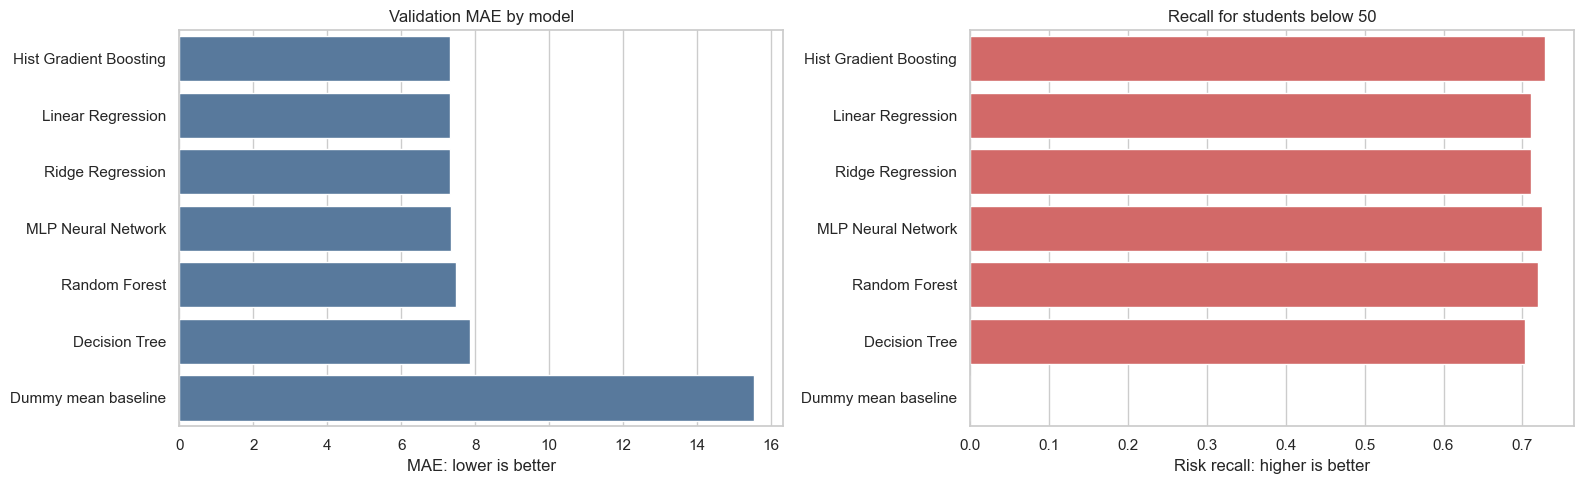

In [ ]:
# Plot the key trade-off between error and risk recall.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=model_comparison, x="valid_MAE", y="model", ax=axes[0], color="#4c78a8")
axes[0].set_title("Validation MAE by model")
axes[0].set_xlabel("MAE: lower is better")
axes[0].set_ylabel("")

sns.barplot(data=model_comparison, x="risk_recall", y="model", ax=axes[1], color="#e45756")
axes[1].set_title("Recall for students below 50")
axes[1].set_xlabel("Risk recall: higher is better")
axes[1].set_ylabel("")

plt.tight_layout()
save_figure("model_validation_and_risk_recall", folder="1_4_3_model_comparison", fig=fig)
plt.show()

### 1.4.4 Cross-Validation

Cross-validation gives a more stable view of model performance than a single validation split.


In [ ]:
# Run cross-validation on the main candidate models.
from sklearn.model_selection import cross_validate, KFold

# Five shuffled folds estimate performance stability.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, estimator in models.items():
    print(f"Cross-validating {name}...")
    pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])
    scores = cross_validate(
        pipeline,
        X_train_model,
        y_train_model,
        cv=cv,
        scoring={"MAE": "neg_mean_absolute_error", "R2": "r2"},
        n_jobs=1,
        pre_dispatch=1,
    )
    cv_rows.append({
        "model": name,
        "cv_MAE_mean": -scores["test_MAE"].mean(),
        "cv_MAE_std": scores["test_MAE"].std(),
        "cv_R2_mean": scores["test_R2"].mean(),
        "cv_R2_std": scores["test_R2"].std(),
    })
    print(f"Finished {name} in {duration_seconds:.1f}s")


In [54]:
# Cross-validation summary.
cv_results = pd.DataFrame(cv_rows).sort_values("cv_MAE_mean")
save_table(cv_results.round(3), "cv_results", folder="1_4_4_cross_validation_results")
cv_results.round(3)

,model,cv_MAE_mean,cv_MAE_std,cv_R2_mean,cv_R2_std
5,Hist Gradient Boosting,7.322,0.051,0.764,0.003
1,Linear Regression,7.332,0.042,0.763,0.003
2,Ridge Regression,7.332,0.042,0.763,0.003
6,MLP Neural Network,7.344,0.044,0.763,0.003
4,Random Forest,7.496,0.045,0.753,0.004
3,Decision Tree,7.901,0.048,0.726,0.004
0,Dummy mean baseline,15.649,0.057,-0.000,0.000


### 1.4.5 Hyperparameter Selection

The tuning step focuses on the strongest model family from the comparison. `RandomizedSearchCV` keeps the search manageable while still testing meaningful parameter combinations.


In [ ]:
# Search hyperparameters for the selected boosting model.
from sklearn.model_selection import RandomizedSearchCV

# Tune the strongest model family from the comparison.
tuning_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
])

param_distributions = {
    # Step size for boosting updates.
    "model__learning_rate": [0.03, 0.05, 0.08, 0.12],
    # Number of boosting rounds.
    "model__max_iter": [150, 250, 400],
    # Leaf count controls model flexibility.
    "model__max_leaf_nodes": [15, 31, 63],
    # L2 regularization.
    "model__l2_regularization": [0.0, 0.01, 0.05, 0.1],
    # Minimum leaf size.
    "model__min_samples_leaf": [20, 50, 100],
}

# Limit the search cost with random trials.
# Three folds keep tuning cost acceptable.
search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
    pre_dispatch=1,
    verbose=2,
)

search.fit(X_train_model, y_train_model)

print("Best MAE from CV:", -search.best_score_)
print("Best parameters:")
search.best_params_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best MAE from CV: 7.321818780813452
Best parameters:


{'model__min_samples_leaf': 50,
 'model__max_leaf_nodes': 31,
 'model__max_iter': 250,
 'model__learning_rate': 0.05,
 'model__l2_regularization': 0.01}

In [ ]:
# Evaluate the tuned model on the validation split.
best_model = search.best_estimator_
best_model_results = pd.DataFrame([
    evaluate_regression_model(
        "Tuned Hist Gradient Boosting",
        best_model,
        X_train_model,
        y_train_model,
        X_valid,
        y_valid,
    )
])

save_model(best_model, "best_hist_gradient_boosting_model", folder="1_4_5_hyperparameter_tuning")
save_json(search.best_params_, "best_model_parameters", folder="1_4_5_hyperparameter_tuning")
save_table(best_model_results.round(3), "best_model_results", folder="1_4_5_hyperparameter_tuning")

pd.concat([model_comparison, best_model_results], ignore_index=True).sort_values("valid_MAE").round(3)

,model,train_MAE,valid_MAE,valid_RMSE,valid_R2,risk_precision,risk_recall,risk_F1,overfit_gap_MAE,fit_seconds
7,Tuned Hist Gradient Boosting,7.166,7.302,9.211,0.762,0.773,0.728,0.750,0.136,NaN
0,Hist Gradient Boosting,7.169,7.307,9.215,0.762,0.773,0.729,0.750,0.138,4.465
1,Linear Regression,7.330,7.331,9.252,0.760,0.783,0.711,0.745,0.001,0.532
2,Ridge Regression,7.330,7.331,9.252,0.760,0.782,0.711,0.745,0.001,0.364
3,MLP Neural Network,7.333,7.345,9.258,0.760,0.773,0.724,0.748,0.012,20.309
4,Random Forest,6.757,7.469,9.423,0.751,0.766,0.719,0.742,0.713,10.591
5,Decision Tree,7.600,7.856,9.908,0.725,0.755,0.703,0.728,0.256,1.115
6,Dummy mean baseline,15.649,15.547,18.898,-0.000,0.000,0.000,0.000,-0.102,0.361


### 1.4.6 Overfitting and Underfitting Analysis

Overfitting is checked by comparing training and validation MAE. A large gap means the model fits the training data too closely; high errors on both sets suggest underfitting.


In [ ]:
# Compare train and validation errors to diagnose overfitting.
overfit_table = pd.concat([model_comparison, best_model_results], ignore_index=True)[[
    "model",
    "train_MAE",
    "valid_MAE",
    "overfit_gap_MAE",
    "valid_R2",
    "risk_recall",
]]

save_table(overfit_table.round(3), "overfitting_comparison", folder="1_4_6_overfitting_analysis")
overfit_table.sort_values("valid_MAE").round(3)

,model,train_MAE,valid_MAE,overfit_gap_MAE,valid_R2,risk_recall
7,Tuned Hist Gradient Boosting,7.166,7.302,0.136,0.762,0.728
0,Hist Gradient Boosting,7.169,7.307,0.138,0.762,0.729
1,Linear Regression,7.330,7.331,0.001,0.760,0.711
2,Ridge Regression,7.330,7.331,0.001,0.760,0.711
3,MLP Neural Network,7.333,7.345,0.012,0.760,0.724
4,Random Forest,6.757,7.469,0.713,0.751,0.719
5,Decision Tree,7.600,7.856,0.256,0.725,0.703
6,Dummy mean baseline,15.649,15.547,-0.102,-0.000,0.000


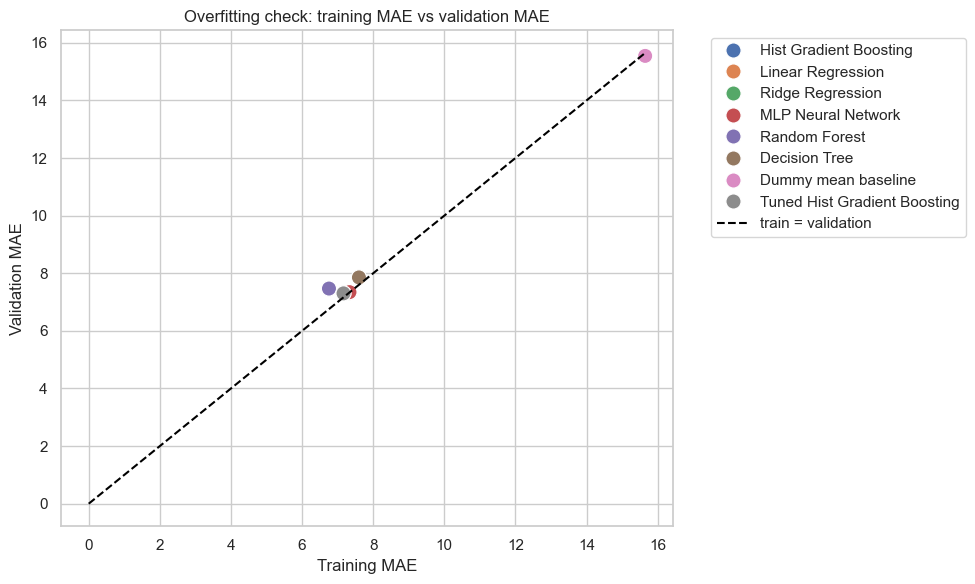

In [ ]:
# Plot the overfitting gap by model.
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=overfit_table,
    x="train_MAE",
    y="valid_MAE",
    hue="model",
    s=120,
    ax=ax,
)
max_error = max(overfit_table["train_MAE"].max(), overfit_table["valid_MAE"].max())
ax.plot([0, max_error], [0, max_error], linestyle="--", color="black", label="train = validation")
ax.set_title("Overfitting check: training MAE vs validation MAE")
ax.set_xlabel("Training MAE")
ax.set_ylabel("Validation MAE")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_figure("overfitting_check_mae", folder="1_4_6_overfitting_analysis", fig=fig)
plt.show()

### 1.4.7 Final Model Choice

The final model is selected mainly on validation MAE, with `risk_recall` and the overfitting gap used as secondary checks.
